<a href="https://colab.research.google.com/github/uvindu827/J26-DS-350/blob/Indhi_Component2_CHL_Forecast/01_Random_Forest_CHL_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================================================
# STEP 31.9P-12 — RANDOM FOREST BASELINE MODEL
# ======================================================================

import sys
import platform

print("=" * 70)
print("STEP 31.9P-12 — RANDOM FOREST BASELINE MODEL")
print("=" * 70)

print("\nPython version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

print("\nRandom Forest training device:")
print("CPU")

STEP 31.9P-12 — RANDOM FOREST BASELINE MODEL

Python version:
3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]

Platform:
Linux-6.6.122+-x86_64-with-glibc2.39

Random Forest training device:
CPU


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/Indhi_Marine_Research_Data"
)

PREPROCESS_DIR = BASE_DIR / "05_model_preprocessing"

MODEL_DIR = (
    BASE_DIR /
    "06_models" /
    "01_Random_Forest"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project directory:")
print(BASE_DIR)

print("\nPreprocessing directory:")
print(PREPROCESS_DIR)

print("\nRandom Forest model directory:")
print(MODEL_DIR)

Project directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data

Preprocessing directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data/05_model_preprocessing

Random Forest model directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
TRAIN_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_train.csv"
)

VALIDATION_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_validation.csv"
)

TEST_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_test.csv"
)

train_df = pd.read_csv(TRAIN_FILE)
validation_df = pd.read_csv(VALIDATION_FILE)
test_df = pd.read_csv(TEST_FILE)

print("=" * 70)
print("MODEL-READY DATASETS LOADED")
print("=" * 70)

print("\nTraining:")
print(train_df.shape)

print("\nValidation:")
print(validation_df.shape)

print("\nTest:")
print(test_df.shape)

MODEL-READY DATASETS LOADED

Training:
(736950, 75)

Validation:
(157896, 75)

Test:
(157998, 75)


In [ ]:
FEATURE_FILE = (
    PREPROCESS_DIR /
    "final_model_feature_columns.csv"
)

feature_df = pd.read_csv(FEATURE_FILE)

FEATURES = (
    feature_df["feature"]
    .dropna()
    .astype(str)
    .tolist()
)

FEATURES = list(dict.fromkeys(FEATURES))

print("=" * 70)
print("FINAL MODEL FEATURES")
print("=" * 70)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, start=1):
    print(f"{i:02d}. {feature}")

FINAL MODEL FEATURES
Number of features: 69
01. sst
02. sss
03. nitrate
04. phosphate
05. silicate
06. year
07. month
08. day
09. day_of_year
10. day_of_week
11. week_of_year
12. day_of_year_sin
13. day_of_year_cos
14. month_sin
15. month_cos
16. day_of_week_sin
17. day_of_week_cos
18. chl_lag_1
19. chl_lag_2
20. chl_lag_3
21. chl_lag_5
22. chl_lag_7
23. chl_lag_14
24. chl_lag_30
25. sst_lag_1
26. sst_lag_3
27. sst_lag_7
28. sst_lag_14
29. sss_lag_1
30. sss_lag_3
31. sss_lag_7
32. sss_lag_14
33. nitrate_lag_1
34. nitrate_lag_3
35. nitrate_lag_7
36. nitrate_lag_14
37. phosphate_lag_1
38. phosphate_lag_3
39. phosphate_lag_7
40. phosphate_lag_14
41. silicate_lag_1
42. silicate_lag_3
43. silicate_lag_7
44. silicate_lag_14
45. chl_rolling_mean_3
46. chl_rolling_mean_7
47. chl_rolling_mean_14
48. chl_rolling_std_7
49. chl_rolling_std_14
50. sst_rolling_mean_3
51. sst_rolling_mean_7
52. sst_rolling_mean_14
53. sss_rolling_mean_3
54. sss_rolling_mean_7
55. sss_rolling_mean_14
56. nitrate_rolli

In [ ]:
TARGET = "chlorophyll_a_log1p"
ORIGINAL_TARGET = "chlorophyll_a"

print("=" * 70)
print("TARGET CONFIGURATION")
print("=" * 70)

print("Model target:", TARGET)
print("Original CHL target:", ORIGINAL_TARGET)

TARGET CONFIGURATION
Model target: chlorophyll_a_log1p
Original CHL target: chlorophyll_a


In [ ]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_validation = validation_df[FEATURES]
y_validation = validation_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("=" * 70)
print("MODEL INPUT SHAPES")
print("=" * 70)

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

MODEL INPUT SHAPES

X_train: (736950, 69)
y_train: (736950,)

X_validation: (157896, 69)
y_validation: (157896,)

X_test: (157998, 69)
y_test: (157998,)


In [ ]:
print("=" * 70)
print("PRE-TRAINING SAFETY CHECKS")
print("=" * 70)

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_validation.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print("\nTarget missing values:")
print("Train:", y_train.isna().sum())
print("Validation:", y_validation.isna().sum())
print("Test:", y_test.isna().sum())

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

assert y_train.isna().sum() == 0
assert y_validation.isna().sum() == 0
assert y_test.isna().sum() == 0

print("\n✓ No missing predictor values.")
print("✓ No missing target values.")
print("✓ Ready for Random Forest training.")

PRE-TRAINING SAFETY CHECKS

Missing values:
Train: 0
Validation: 0
Test: 0

Target missing values:
Train: 0
Validation: 0
Test: 0

✓ No missing predictor values.
✓ No missing target values.
✓ Ready for Random Forest training.


In [ ]:
# ======================================================================
# STEP 31.9P-12A — RANDOM FOREST TRAINING
# ======================================================================

import time
import joblib
from sklearn.ensemble import RandomForestRegressor

print("=" * 70)
print("STEP 31.9P-12A — RANDOM FOREST TRAINING")
print("=" * 70)

# ----------------------------------------------------------------------
# RANDOM FOREST CONFIGURATION
# ----------------------------------------------------------------------

RF_CONFIG = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": -1
}

print("\n" + "=" * 70)
print("RANDOM FOREST CONFIGURATION")
print("=" * 70)

for parameter, value in RF_CONFIG.items():
    print(f"{parameter:20s}: {value}")

# ----------------------------------------------------------------------
# CREATE MODEL
# ----------------------------------------------------------------------

rf_model = RandomForestRegressor(
    **RF_CONFIG
)

print("\n" + "=" * 70)
print("MODEL CREATED")
print("=" * 70)

print("Model type:")
print(type(rf_model).__name__)

# ----------------------------------------------------------------------
# TRAIN MODEL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

print("Training rows :", X_train.shape[0])
print("Training features :", X_train.shape[1])
print("Training target :", TARGET)

print("\nCPU parallel processing:")
print("n_jobs =", RF_CONFIG["n_jobs"])

print("\nTraining started...")

training_start = time.time()

rf_model.fit(
    X_train,
    y_train
)

training_end = time.time()

training_time_seconds = training_end - training_start
training_time_minutes = training_time_seconds / 60

print("\n✓ Random Forest training completed.")

print(f"\nTraining time:")
print(f"{training_time_seconds:.2f} seconds")
print(f"{training_time_minutes:.2f} minutes")

# ----------------------------------------------------------------------
# VALIDATION PREDICTIONS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERATING VALIDATION PREDICTIONS")
print("=" * 70)

validation_prediction_start = time.time()

y_validation_pred_log = rf_model.predict(
    X_validation
)

validation_prediction_end = time.time()

prediction_time_seconds = (
    validation_prediction_end -
    validation_prediction_start
)

print("✓ Validation predictions generated.")

print(
    f"Prediction time: "
    f"{prediction_time_seconds:.2f} seconds"
)

print("\nPrediction shape:")
print(y_validation_pred_log.shape)

# ----------------------------------------------------------------------
# BACK-TRANSFORM TO ORIGINAL CHL SCALE
# ----------------------------------------------------------------------

y_validation_pred_chl = np.expm1(
    y_validation_pred_log
)

y_validation_actual_chl = validation_df[
    ORIGINAL_TARGET
].to_numpy()

# Prevent tiny numerical negative values
y_validation_pred_chl = np.maximum(
    y_validation_pred_chl,
    0
)

print("\n" + "=" * 70)
print("VALIDATION PREDICTION RANGE")
print("=" * 70)

print(
    "Predicted log1p CHL:"
)

print(
    f"Minimum: {y_validation_pred_log.min():.6f}"
)

print(
    f"Maximum: {y_validation_pred_log.max():.6f}"
)

print(
    "\nPredicted original CHL:"
)

print(
    f"Minimum: {y_validation_pred_chl.min():.6f} mg/m³"
)

print(
    f"Maximum: {y_validation_pred_chl.max():.6f} mg/m³"
)

print(
    "\nActual validation CHL:"
)

print(
    f"Minimum: {y_validation_actual_chl.min():.6f} mg/m³"
)

print(
    f"Maximum: {y_validation_actual_chl.max():.6f} mg/m³"
)

# ----------------------------------------------------------------------
# SAVE MODEL
# ----------------------------------------------------------------------

MODEL_FILE = (
    MODEL_DIR /
    "random_forest_chlorophyll_model.joblib"
)

joblib.dump(
    rf_model,
    MODEL_FILE
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(MODEL_FILE)

# ----------------------------------------------------------------------
# SAVE MODEL CONFIGURATION
# ----------------------------------------------------------------------

config_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "target": TARGET,
        "number_of_features": len(FEATURES),
        "training_rows": len(X_train),
        "validation_rows": len(X_validation),
        "n_estimators": RF_CONFIG["n_estimators"],
        "max_depth": RF_CONFIG["max_depth"],
        "min_samples_leaf": RF_CONFIG["min_samples_leaf"],
        "max_features": RF_CONFIG["max_features"],
        "random_state": RF_CONFIG["random_state"],
        "n_jobs": RF_CONFIG["n_jobs"],
        "training_time_seconds": training_time_seconds,
        "training_time_minutes": training_time_minutes
    }
])

CONFIG_FILE = (
    MODEL_DIR /
    "random_forest_training_configuration.csv"
)

config_df.to_csv(
    CONFIG_FILE,
    index=False
)

print("\nConfiguration saved:")
print(CONFIG_FILE)

# ----------------------------------------------------------------------
# SAVE VALIDATION PREDICTIONS
# ----------------------------------------------------------------------

validation_predictions = pd.DataFrame({
    "date": validation_df["date"].values,
    "latitude": validation_df["latitude"].values,
    "longitude": validation_df["longitude"].values,
    "actual_chlorophyll_a": y_validation_actual_chl,
    "actual_chlorophyll_a_log1p": y_validation[TARGET].values,
    "predicted_chlorophyll_a_log1p": y_validation_pred_log,
    "predicted_chlorophyll_a": y_validation_pred_chl
})

VALIDATION_PREDICTIONS_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

validation_predictions.to_csv(
    VALIDATION_PREDICTIONS_FILE,
    index=False
)

print("\nValidation predictions saved:")
print(VALIDATION_PREDICTIONS_FILE)

# ----------------------------------------------------------------------
# FINAL STATUS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 31.9P-12A COMPLETE")
print("=" * 70)

print("✓ Random Forest trained using training data only.")
print("✓ Validation predictions generated.")
print("✓ Predictions converted back to original CHL scale.")
print("✓ Trained model saved.")
print("✓ Training configuration saved.")
print("✓ Validation predictions saved.")

print("\nIMPORTANT:")
print("✓ Test data has NOT been used.")
print("✓ Test predictions have NOT been generated.")
print("✓ Final test evaluation remains untouched.")

print("\nNext:")
print("STEP 31.9P-12B — RANDOM FOREST VALIDATION EVALUATION")

STEP 31.9P-12A — RANDOM FOREST TRAINING

RANDOM FOREST CONFIGURATION
n_estimators        : 300
max_depth           : 20
min_samples_leaf    : 5
max_features        : sqrt
random_state        : 42
n_jobs              : -1

MODEL CREATED
Model type:
RandomForestRegressor

TRAINING RANDOM FOREST
Training rows : 736950
Training features : 69
Training target : chlorophyll_a_log1p

CPU parallel processing:
n_jobs = -1

Training started...

✓ Random Forest training completed.

Training time:
2555.58 seconds
42.59 minutes

GENERATING VALIDATION PREDICTIONS
✓ Validation predictions generated.
Prediction time: 6.75 seconds

Prediction shape:
(157896,)

VALIDATION PREDICTION RANGE
Predicted log1p CHL:
Minimum: 0.092716
Maximum: 2.209249

Predicted original CHL:
Minimum: 0.097150 mg/m³
Maximum: 8.108876 mg/m³

Actual validation CHL:
Minimum: 0.066738 mg/m³
Maximum: 37.501720 mg/m³

MODEL SAVED
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/random_forest_chlorophyll_mo

KeyError: 'chlorophyll_a_log1p'

In [ ]:
# ======================================================================
# STEP 31.9P-12A RECOVERY — SAVE VALIDATION PREDICTIONS
# ======================================================================

print("=" * 70)
print("STEP 31.9P-12A RECOVERY — SAVE VALIDATION PREDICTIONS")
print("=" * 70)

# y_validation is already a Series
y_validation_actual_log = y_validation.to_numpy()

validation_predictions = pd.DataFrame({
    "date": validation_df["date"].values,
    "latitude": validation_df["latitude"].values,
    "longitude": validation_df["longitude"].values,
    "actual_chlorophyll_a": y_validation_actual_chl,
    "actual_chlorophyll_a_log1p": y_validation_actual_log,
    "predicted_chlorophyll_a_log1p": y_validation_pred_log,
    "predicted_chlorophyll_a": y_validation_pred_chl
})

VALIDATION_PREDICTIONS_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

validation_predictions.to_csv(
    VALIDATION_PREDICTIONS_FILE,
    index=False
)

print("\n✓ Validation predictions saved successfully.")

print("\nFile:")
print(VALIDATION_PREDICTIONS_FILE)

print("\nShape:")
print(validation_predictions.shape)

print("\nColumns:")
for column in validation_predictions.columns:
    print("✓", column)

print("\nFirst 5 predictions:")
print(validation_predictions.head())

print("\n" + "=" * 70)
print("STEP 31.9P-12A COMPLETE")
print("=" * 70)

print("✓ Random Forest training completed.")
print("✓ Model saved.")
print("✓ Training configuration saved.")
print("✓ Validation predictions saved.")
print("✓ Test data was NOT used.")

STEP 31.9P-12A RECOVERY — SAVE VALIDATION PREDICTIONS

✓ Validation predictions saved successfully.

File:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/random_forest_validation_predictions.csv

Shape:
(157896, 7)

Columns:
✓ date
✓ latitude
✓ longitude
✓ actual_chlorophyll_a
✓ actual_chlorophyll_a_log1p
✓ predicted_chlorophyll_a_log1p
✓ predicted_chlorophyll_a

First 5 predictions:
         date  latitude  longitude  actual_chlorophyll_a  \
0  2017-07-10  5.833334  79.333336              0.316412   
1  2017-07-10  5.833334  79.416664              0.324167   
2  2017-07-10  5.833334  79.500000              0.329531   
3  2017-07-10  5.833334  79.583336              0.343342   
4  2017-07-10  5.833334  79.666664              0.357804   

   actual_chlorophyll_a_log1p  predicted_chlorophyll_a_log1p  \
0                    0.274910                       0.379250   
1                    0.280783                       0.390727   
2                    0.284826 

STEP 31.9P-12B — COMPREHENSIVE RANDOM FOREST VALIDATION EVALUATION

Output directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation

LOADING VALIDATION PREDICTIONS

Shape:
(157896, 7)

Columns:
✓ date
✓ latitude
✓ longitude
✓ actual_chlorophyll_a
✓ actual_chlorophyll_a_log1p
✓ predicted_chlorophyll_a_log1p
✓ predicted_chlorophyll_a

VALIDATION PREDICTION INTEGRITY CHECK
✓ All required prediction columns are present.

Missing values:
date                             0
latitude                         0
longitude                        0
actual_chlorophyll_a             0
actual_chlorophyll_a_log1p       0
predicted_chlorophyll_a_log1p    0
predicted_chlorophyll_a          0
dtype: int64

✓ No missing values.

REGRESSION PERFORMANCE — LOG1P CHL SCALE
MAE                  : 0.073968
RMSE                 : 0.154195
R²                   : 0.834775
Median Absolute Error: 0.028992
Explained Variance   : 0.835018
Pearson r            : 0.917177
Spearma

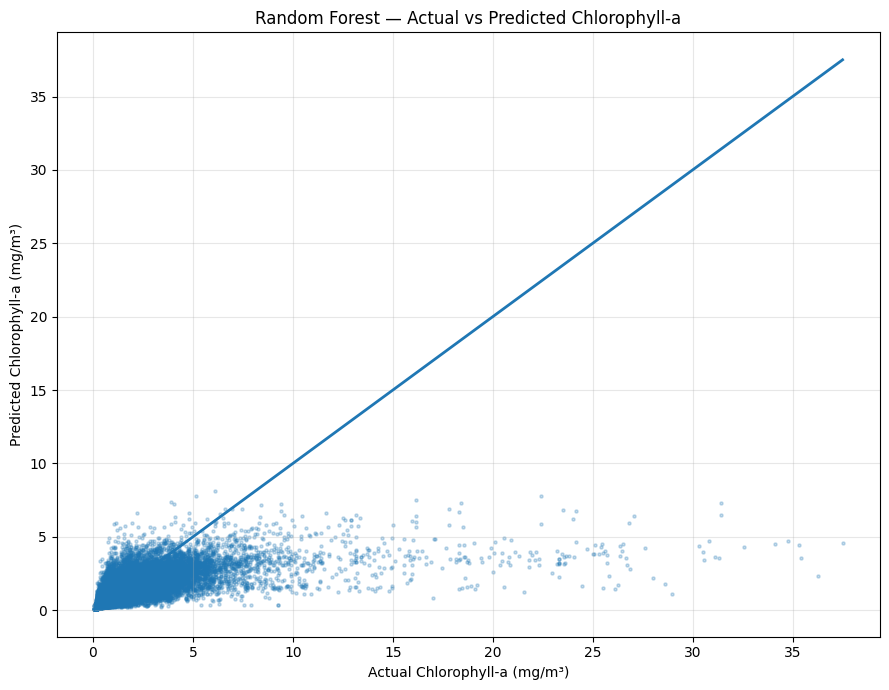

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_actual_vs_predicted.png

CREATING RESIDUAL DISTRIBUTION


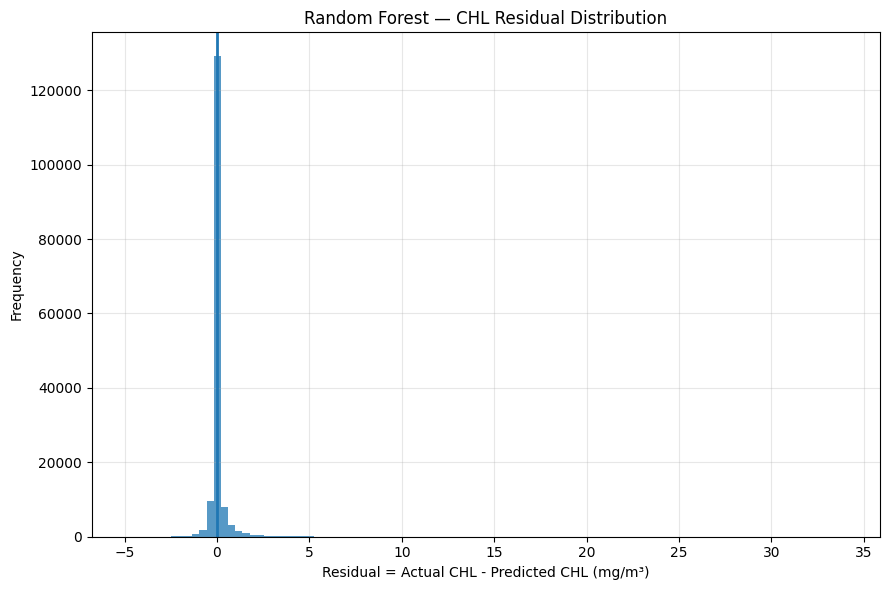

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_residual_distribution.png

DERIVING CHL PRODUCTIVITY THRESHOLDS
50th percentile: 0.298395 mg/m³
75th percentile: 0.545567 mg/m³
90th percentile: 0.922410 mg/m³
95th percentile: 1.304732 mg/m³
99th percentile: 3.127116 mg/m³

Primary high-productivity threshold: 0.545567 mg/m³

HIGH-CHL EVENT DETECTION

75th percentile threshold = 0.545567 mg/m³
Actual events    : 47,730
Predicted events : 50,547
Accuracy          : 0.9437
Precision         : 0.8841
Detection/Recall  : 0.9363
F1-score          : 0.9095
Specificity       : 0.9468
False alarm rate  : 0.0532

90th percentile threshold = 0.922410 mg/m³
Actual events    : 31,000
Predicted events : 31,517
Accuracy          : 0.9509
Precision         : 0.8688
Detection/Recall  : 0.8833
F1-score          : 0.8760
Specificity       : 0.9674
False alarm rate  : 0.0326

95th percentile threshold = 1.304732 mg/m³
Actual events    : 20,587
Pr

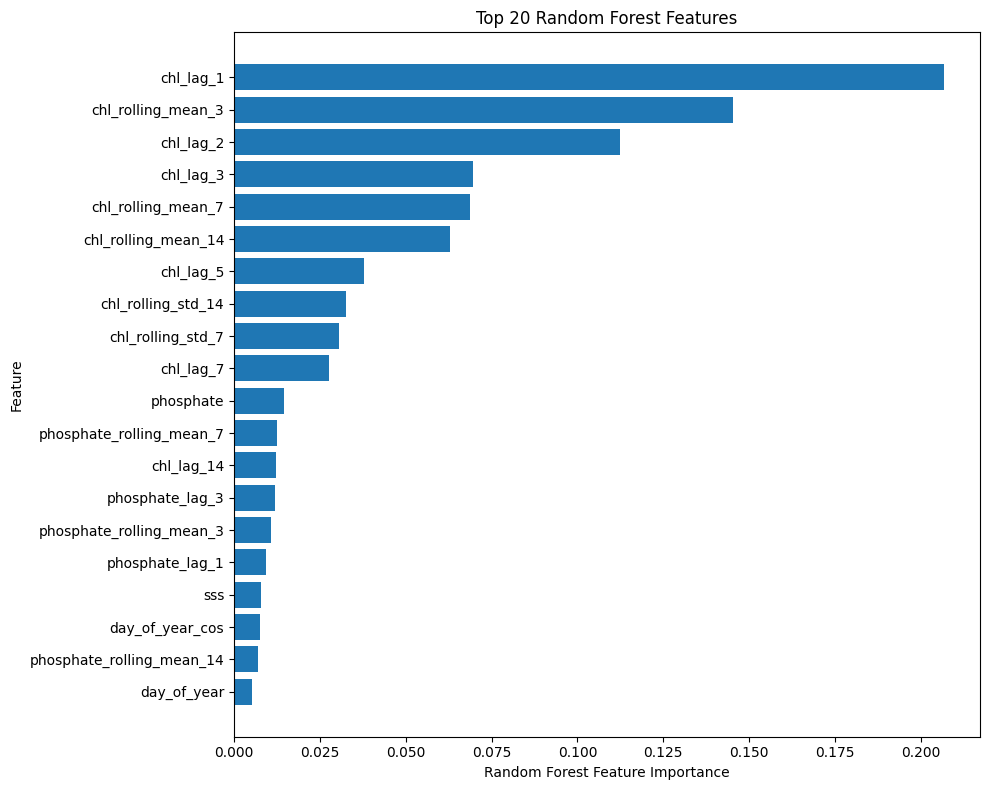

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_top20_feature_importance.png

SAVING COMPLETE VALIDATION PREDICTIONS
Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_validation_predictions_with_diagnostics.csv

STEP 31.9P-12B COMPLETE

OVERALL PERFORMANCE
MAE  : 0.196703 mg/m³
RMSE : 0.817120 mg/m³
R²   : 0.524387
Bias : -0.074536 mg/m³

HIGH-CHL EVENT PERFORMANCE
 percentile  threshold_mg_m3  precision  recall_detection_rate  f1_score  false_alarm_rate
         75         0.545567   0.884147               0.936329  0.909491          0.053156
         90         0.922410   0.868769               0.883258  0.875954          0.032594
         95         1.304732   0.825260               0.794433  0.809553          0.025220
         99         3.127116   0.738600               0.264977  0.390029          0.002650

SPATIAL LOCATIONS EVALUATED:
102

FEATURES EVALUATED:
69

In [ ]:
# ======================================================================
# STEP 31.9P-12B — COMPREHENSIVE RANDOM FOREST VALIDATION EVALUATION
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from scipy.stats import pearsonr, spearmanr

print("=" * 70)
print("STEP 31.9P-12B — COMPREHENSIVE RANDOM FOREST VALIDATION EVALUATION")
print("=" * 70)

# ======================================================================
# 1. PATHS
# ======================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Indhi_Marine_Research_Data"
)

PREPROCESS_DIR = BASE_DIR / "05_model_preprocessing"

MODEL_DIR = (
    BASE_DIR /
    "06_models" /
    "01_Random_Forest"
)

PREDICTION_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

MODEL_FILE = (
    MODEL_DIR /
    "random_forest_chlorophyll_model.joblib"
)

FEATURE_FILE = (
    PREPROCESS_DIR /
    "final_model_feature_columns.csv"
)

OUTPUT_DIR = MODEL_DIR / "evaluation"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nOutput directory:")
print(OUTPUT_DIR)

# ======================================================================
# 2. LOAD VALIDATION PREDICTIONS
# ======================================================================

print("\n" + "=" * 70)
print("LOADING VALIDATION PREDICTIONS")
print("=" * 70)

pred_df = pd.read_csv(
    PREDICTION_FILE,
    parse_dates=["date"]
)

print("\nShape:")
print(pred_df.shape)

print("\nColumns:")
for column in pred_df.columns:
    print("✓", column)

# ======================================================================
# 3. BASIC INTEGRITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("VALIDATION PREDICTION INTEGRITY CHECK")
print("=" * 70)

required_columns = [
    "date",
    "latitude",
    "longitude",
    "actual_chlorophyll_a",
    "actual_chlorophyll_a_log1p",
    "predicted_chlorophyll_a_log1p",
    "predicted_chlorophyll_a",
]

missing_columns = [
    column
    for column in required_columns
    if column not in pred_df.columns
]

assert len(missing_columns) == 0, (
    f"Missing columns: {missing_columns}"
)

print("✓ All required prediction columns are present.")

print("\nMissing values:")

print(
    pred_df[
        required_columns
    ].isna().sum()
)

assert (
    pred_df[
        required_columns
    ].isna().sum().sum()
    == 0
)

print("\n✓ No missing values.")

# ======================================================================
# 4. EXTRACT TARGETS AND PREDICTIONS
# ======================================================================

actual_log = (
    pred_df["actual_chlorophyll_a_log1p"]
    .to_numpy()
)

predicted_log = (
    pred_df["predicted_chlorophyll_a_log1p"]
    .to_numpy()
)

actual_chl = (
    pred_df["actual_chlorophyll_a"]
    .to_numpy()
)

predicted_chl = (
    pred_df["predicted_chlorophyll_a"]
    .to_numpy()
)

# ======================================================================
# 5. RESIDUALS
# ======================================================================

pred_df["residual_log"] = (
    actual_log - predicted_log
)

pred_df["absolute_error_log"] = (
    np.abs(pred_df["residual_log"])
)

pred_df["squared_error_log"] = (
    pred_df["residual_log"] ** 2
)

pred_df["residual_chl"] = (
    actual_chl - predicted_chl
)

pred_df["absolute_error_chl"] = (
    np.abs(pred_df["residual_chl"])
)

pred_df["squared_error_chl"] = (
    pred_df["residual_chl"] ** 2
)

# ======================================================================
# 6. CONTINUOUS REGRESSION METRICS — LOG SCALE
# ======================================================================

print("\n" + "=" * 70)
print("REGRESSION PERFORMANCE — LOG1P CHL SCALE")
print("=" * 70)

mae_log = mean_absolute_error(
    actual_log,
    predicted_log
)

rmse_log = np.sqrt(
    mean_squared_error(
        actual_log,
        predicted_log
    )
)

r2_log = r2_score(
    actual_log,
    predicted_log
)

median_ae_log = median_absolute_error(
    actual_log,
    predicted_log
)

explained_variance_log = explained_variance_score(
    actual_log,
    predicted_log
)

pearson_log, pearson_log_p = pearsonr(
    actual_log,
    predicted_log
)

spearman_log, spearman_log_p = spearmanr(
    actual_log,
    predicted_log
)

bias_log = np.mean(
    predicted_log - actual_log
)

print(f"MAE                  : {mae_log:.6f}")
print(f"RMSE                 : {rmse_log:.6f}")
print(f"R²                   : {r2_log:.6f}")
print(f"Median Absolute Error: {median_ae_log:.6f}")
print(f"Explained Variance   : {explained_variance_log:.6f}")
print(f"Pearson r            : {pearson_log:.6f}")
print(f"Spearman r           : {spearman_log:.6f}")
print(f"Mean Prediction Bias : {bias_log:.6f}")

# ======================================================================
# 7. CONTINUOUS REGRESSION METRICS — ORIGINAL CHL SCALE
# ======================================================================

print("\n" + "=" * 70)
print("REGRESSION PERFORMANCE — ORIGINAL CHL SCALE")
print("=" * 70)

mae_chl = mean_absolute_error(
    actual_chl,
    predicted_chl
)

rmse_chl = np.sqrt(
    mean_squared_error(
        actual_chl,
        predicted_chl
    )
)

r2_chl = r2_score(
    actual_chl,
    predicted_chl
)

median_ae_chl = median_absolute_error(
    actual_chl,
    predicted_chl
)

explained_variance_chl = explained_variance_score(
    actual_chl,
    predicted_chl
)

pearson_chl, pearson_chl_p = pearsonr(
    actual_chl,
    predicted_chl
)

spearman_chl, spearman_chl_p = spearmanr(
    actual_chl,
    predicted_chl
)

bias_chl = np.mean(
    predicted_chl - actual_chl
)

mean_absolute_percentage_error_chl = (
    np.mean(
        np.abs(
            (actual_chl - predicted_chl)
            /
            np.maximum(
                np.abs(actual_chl),
                1e-8
            )
        )
    )
    * 100
)

print(f"MAE                  : {mae_chl:.6f} mg/m³")
print(f"RMSE                 : {rmse_chl:.6f} mg/m³")
print(f"R²                   : {r2_chl:.6f}")
print(f"Median Absolute Error: {median_ae_chl:.6f} mg/m³")
print(f"Explained Variance   : {explained_variance_chl:.6f}")
print(f"Pearson r            : {pearson_chl:.6f}")
print(f"Spearman r           : {spearman_chl:.6f}")
print(f"Mean Prediction Bias : {bias_chl:.6f} mg/m³")
print(
    f"MAPE                 : "
    f"{mean_absolute_percentage_error_chl:.2f}%"
)

# ======================================================================
# 8. PREDICTION RANGE CHECK
# ======================================================================

print("\n" + "=" * 70)
print("PREDICTION RANGE CHECK")
print("=" * 70)

print(
    f"Actual CHL minimum     : "
    f"{actual_chl.min():.6f}"
)

print(
    f"Actual CHL maximum     : "
    f"{actual_chl.max():.6f}"
)

print(
    f"Predicted CHL minimum  : "
    f"{predicted_chl.min():.6f}"
)

print(
    f"Predicted CHL maximum  : "
    f"{predicted_chl.max():.6f}"
)

# ======================================================================
# 9. OVERALL REGRESSION METRICS TABLE
# ======================================================================

metrics_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "evaluation_split": "Validation",
        "MAE_log1p": mae_log,
        "RMSE_log1p": rmse_log,
        "R2_log1p": r2_log,
        "MedianAE_log1p": median_ae_log,
        "ExplainedVariance_log1p": explained_variance_log,
        "Pearson_r_log1p": pearson_log,
        "Spearman_r_log1p": spearman_log,
        "Bias_log1p": bias_log,
        "MAE_CHL_mg_m3": mae_chl,
        "RMSE_CHL_mg_m3": rmse_chl,
        "R2_CHL": r2_chl,
        "MedianAE_CHL_mg_m3": median_ae_chl,
        "ExplainedVariance_CHL": explained_variance_chl,
        "Pearson_r_CHL": pearson_chl,
        "Spearman_r_CHL": spearman_chl,
        "Bias_CHL_mg_m3": bias_chl,
        "MAPE_CHL_percent": mean_absolute_percentage_error_chl,
    }
])

METRICS_FILE = (
    OUTPUT_DIR /
    "random_forest_validation_regression_metrics.csv"
)

metrics_df.to_csv(
    METRICS_FILE,
    index=False
)

print("\nMetrics saved:")
print(METRICS_FILE)

# ======================================================================
# 10. ACTUAL VS PREDICTED SCATTER
# ======================================================================

print("\n" + "=" * 70)
print("CREATING ACTUAL VS PREDICTED PLOT")
print("=" * 70)

plt.figure(figsize=(9, 7))

plt.scatter(
    actual_chl,
    predicted_chl,
    s=5,
    alpha=0.25
)

min_value = min(
    actual_chl.min(),
    predicted_chl.min()
)

max_value = max(
    actual_chl.max(),
    predicted_chl.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2
)

plt.xlabel(
    "Actual Chlorophyll-a (mg/m³)"
)

plt.ylabel(
    "Predicted Chlorophyll-a (mg/m³)"
)

plt.title(
    "Random Forest — Actual vs Predicted Chlorophyll-a"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

SCATTER_FILE = (
    OUTPUT_DIR /
    "random_forest_actual_vs_predicted.png"
)

plt.savefig(
    SCATTER_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(SCATTER_FILE)

# ======================================================================
# 11. RESIDUAL DISTRIBUTION
# ======================================================================

print("\n" + "=" * 70)
print("CREATING RESIDUAL DISTRIBUTION")
print("=" * 70)

plt.figure(figsize=(9, 6))

plt.hist(
    pred_df["residual_chl"],
    bins=100,
    alpha=0.75
)

plt.axvline(
    0,
    linewidth=2
)

plt.xlabel(
    "Residual = Actual CHL - Predicted CHL (mg/m³)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Random Forest — CHL Residual Distribution"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

RESIDUAL_FILE = (
    OUTPUT_DIR /
    "random_forest_residual_distribution.png"
)

plt.savefig(
    RESIDUAL_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(RESIDUAL_FILE)

# ======================================================================
# 12. RESIDUAL STATISTICS
# ======================================================================

residual_summary = pd.DataFrame([
    {
        "mean_residual": pred_df["residual_chl"].mean(),
        "median_residual": pred_df["residual_chl"].median(),
        "std_residual": pred_df["residual_chl"].std(),
        "minimum_residual": pred_df["residual_chl"].min(),
        "maximum_residual": pred_df["residual_chl"].max(),
        "mean_absolute_residual": pred_df["absolute_error_chl"].mean(),
        "residual_below_zero_count": (
            (pred_df["residual_chl"] < 0).sum()
        ),
        "residual_above_zero_count": (
            (pred_df["residual_chl"] > 0).sum()
        )
    }
])

RESIDUAL_SUMMARY_FILE = (
    OUTPUT_DIR /
    "random_forest_residual_summary.csv"
)

residual_summary.to_csv(
    RESIDUAL_SUMMARY_FILE,
    index=False
)

# ======================================================================
# 13. TRAINING-DERIVED CHL THRESHOLDS
# ======================================================================

print("\n" + "=" * 70)
print("DERIVING CHL PRODUCTIVITY THRESHOLDS")
print("=" * 70)

# IMPORTANT:
# Thresholds are calculated from TRAINING CHL only.
# Validation data is NOT used to define the thresholds.

TRAIN_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_train.csv"
)

train_for_thresholds = pd.read_csv(
    TRAIN_FILE,
    usecols=["chlorophyll_a"]
)

training_chl = (
    train_for_thresholds["chlorophyll_a"]
    .dropna()
)

threshold_percentiles = [
    50,
    75,
    90,
    95,
    99
]

threshold_values = {
    percentile: np.percentile(
        training_chl,
        percentile
    )
    for percentile in threshold_percentiles
}

for percentile, value in threshold_values.items():
    print(
        f"{percentile}th percentile: "
        f"{value:.6f} mg/m³"
    )

# We will use 75th percentile as the preliminary
# high-productivity threshold for event analysis.
#
# IMPORTANT:
# This is a deliberately explicit threshold choice.
# We will also evaluate 90th/95th/99th percentile events.

HIGH_THRESHOLD = threshold_values[75]

print(
    f"\nPrimary high-productivity threshold: "
    f"{HIGH_THRESHOLD:.6f} mg/m³"
)

# ======================================================================
# 14. HIGH-CHL EVENT EVALUATION
# ======================================================================

print("\n" + "=" * 70)
print("HIGH-CHL EVENT DETECTION")
print("=" * 70)

event_results = []

event_percentiles = [
    75,
    90,
    95,
    99
]

for percentile in event_percentiles:

    threshold = threshold_values.get(
        percentile,
        np.percentile(
            training_chl,
            percentile
        )
    )

    actual_event = (
        actual_chl >= threshold
    )

    predicted_event = (
        predicted_chl >= threshold
    )

    accuracy = accuracy_score(
        actual_event,
        predicted_event
    )

    precision = precision_score(
        actual_event,
        predicted_event,
        zero_division=0
    )

    recall = recall_score(
        actual_event,
        predicted_event,
        zero_division=0
    )

    f1 = f1_score(
        actual_event,
        predicted_event,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        actual_event,
        predicted_event,
        labels=[False, True]
    ).ravel()

    detection_rate = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    false_alarm_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    event_prevalence = (
        actual_event.mean()
    )

    event_results.append({
        "percentile": percentile,
        "threshold_mg_m3": threshold,
        "actual_event_count": int(actual_event.sum()),
        "predicted_event_count": int(predicted_event.sum()),
        "event_prevalence": event_prevalence,
        "accuracy": accuracy,
        "precision": precision,
        "recall_detection_rate": detection_rate,
        "f1_score": f1,
        "specificity": specificity,
        "false_alarm_rate": false_alarm_rate,
        "true_positive": int(tp),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn)
    })

    print(
        f"\n{percentile}th percentile "
        f"threshold = {threshold:.6f} mg/m³"
    )

    print(
        f"Actual events    : {actual_event.sum():,}"
    )

    print(
        f"Predicted events : {predicted_event.sum():,}"
    )

    print(
        f"Accuracy          : {accuracy:.4f}"
    )

    print(
        f"Precision         : {precision:.4f}"
    )

    print(
        f"Detection/Recall  : {detection_rate:.4f}"
    )

    print(
        f"F1-score          : {f1:.4f}"
    )

    print(
        f"Specificity       : {specificity:.4f}"
    )

    print(
        f"False alarm rate  : {false_alarm_rate:.4f}"
    )

event_metrics_df = pd.DataFrame(
    event_results
)

EVENT_METRICS_FILE = (
    OUTPUT_DIR /
    "random_forest_high_chl_event_metrics.csv"
)

event_metrics_df.to_csv(
    EVENT_METRICS_FILE,
    index=False
)

print("\nHigh-CHL event metrics saved:")
print(EVENT_METRICS_FILE)

# ======================================================================
# 15. CONFUSION MATRICES FOR HIGH-CHL EVENTS
# ======================================================================

print("\n" + "=" * 70)
print("HIGH-CHL CONFUSION MATRICES")
print("=" * 70)

for percentile in event_percentiles:

    threshold = threshold_values[
        percentile
    ]

    actual_event = (
        actual_chl >= threshold
    )

    predicted_event = (
        predicted_chl >= threshold
    )

    cm = confusion_matrix(
        actual_event,
        predicted_event,
        labels=[False, True]
    )

    print(
        f"\n{percentile}th percentile "
        f"threshold = {threshold:.6f}"
    )

    print(
        "Rows = Actual [Not High, High]"
    )

    print(
        "Columns = Predicted [Not High, High]"
    )

    print(cm)

# ======================================================================
# 16. MONTHLY PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("MONTHLY PERFORMANCE")
print("=" * 70)

pred_df["year"] = (
    pred_df["date"].dt.year
)

pred_df["month"] = (
    pred_df["date"].dt.month
)

pred_df["month_name"] = (
    pred_df["date"].dt.month_name()
)

monthly_results = []

for month in sorted(
    pred_df["month"].unique()
):

    subset = pred_df[
        pred_df["month"] == month
    ]

    if len(subset) < 2:
        continue

    actual = subset[
        "actual_chlorophyll_a"
    ]

    predicted = subset[
        "predicted_chlorophyll_a"
    ]

    monthly_results.append({
        "month": month,
        "month_name": subset[
            "month_name"
        ].iloc[0],
        "observations": len(subset),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "R2": r2_score(
            actual,
            predicted
        ),
        "bias": np.mean(
            predicted - actual
        )
    })

monthly_df = pd.DataFrame(
    monthly_results
)

MONTHLY_FILE = (
    OUTPUT_DIR /
    "random_forest_monthly_performance.csv"
)

monthly_df.to_csv(
    MONTHLY_FILE,
    index=False
)

print(monthly_df.to_string(index=False))

# ======================================================================
# 17. YEARLY PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("YEARLY PERFORMANCE")
print("=" * 70)

yearly_results = []

for year in sorted(
    pred_df["year"].unique()
):

    subset = pred_df[
        pred_df["year"] == year
    ]

    if len(subset) < 2:
        continue

    actual = subset[
        "actual_chlorophyll_a"
    ]

    predicted = subset[
        "predicted_chlorophyll_a"
    ]

    yearly_results.append({
        "year": year,
        "observations": len(subset),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "R2": r2_score(
            actual,
            predicted
        ),
        "bias": np.mean(
            predicted - actual
        )
    })

yearly_df = pd.DataFrame(
    yearly_results
)

YEARLY_FILE = (
    OUTPUT_DIR /
    "random_forest_yearly_performance.csv"
)

yearly_df.to_csv(
    YEARLY_FILE,
    index=False
)

print(yearly_df.to_string(index=False))

# ======================================================================
# 18. SPATIAL PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("SPATIAL PERFORMANCE — 102 LOCATIONS")
print("=" * 70)

spatial_results = []

for (
    latitude,
    longitude
), subset in pred_df.groupby(
    ["latitude", "longitude"]
):

    actual = subset[
        "actual_chlorophyll_a"
    ]

    predicted = subset[
        "predicted_chlorophyll_a"
    ]

    spatial_results.append({
        "latitude": latitude,
        "longitude": longitude,
        "observations": len(subset),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "R2": (
            r2_score(
                actual,
                predicted
            )
            if actual.nunique() > 1
            else np.nan
        ),
        "bias": np.mean(
            predicted - actual
        ),
        "actual_mean_CHL": actual.mean(),
        "predicted_mean_CHL": predicted.mean(),
        "actual_max_CHL": actual.max(),
        "predicted_max_CHL": predicted.max()
    })

spatial_df = pd.DataFrame(
    spatial_results
)

SPATIAL_FILE = (
    OUTPUT_DIR /
    "random_forest_spatial_performance.csv"
)

spatial_df.to_csv(
    SPATIAL_FILE,
    index=False
)

print(
    f"Locations evaluated: "
    f"{len(spatial_df)}"
)

print("\nBest 10 locations by RMSE:")

print(
    spatial_df.sort_values(
        "RMSE"
    ).head(10).to_string(
        index=False
    )
)

print("\nWorst 10 locations by RMSE:")

print(
    spatial_df.sort_values(
        "RMSE",
        ascending=False
    ).head(10).to_string(
        index=False
    )
)

# ======================================================================
# 19. FEATURE IMPORTANCE
# ======================================================================

print("\n" + "=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

import joblib

rf_model = joblib.load(
    MODEL_FILE
)

feature_importances = (
    rf_model.feature_importances_
)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": feature_importances
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df["rank"] = (
    np.arange(
        1,
        len(importance_df) + 1
    )
)

IMPORTANCE_FILE = (
    OUTPUT_DIR /
    "random_forest_feature_importance.csv"
)

importance_df.to_csv(
    IMPORTANCE_FILE,
    index=False
)

print(
    importance_df.head(30).to_string(
        index=False
    )
)

print("\nFeature importance saved:")
print(IMPORTANCE_FILE)

# ======================================================================
# 20. FEATURE IMPORTANCE PLOT
# ======================================================================

top_n = 20

top_features = (
    importance_df
    .head(top_n)
    .sort_values(
        "importance"
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel(
    "Random Forest Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Random Forest Features"
)

plt.tight_layout()

IMPORTANCE_PLOT = (
    OUTPUT_DIR /
    "random_forest_top20_feature_importance.png"
)

plt.savefig(
    IMPORTANCE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(IMPORTANCE_PLOT)

# ======================================================================
# 21. SAVE COMPLETE VALIDATION RESULTS
# ======================================================================

print("\n" + "=" * 70)
print("SAVING COMPLETE VALIDATION PREDICTIONS")
print("=" * 70)

COMPLETE_PREDICTIONS_FILE = (
    OUTPUT_DIR /
    "random_forest_validation_predictions_with_diagnostics.csv"
)

pred_df.to_csv(
    COMPLETE_PREDICTIONS_FILE,
    index=False
)

print(
    "Saved:"
)

print(
    COMPLETE_PREDICTIONS_FILE
)

# ======================================================================
# 22. FINAL SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("STEP 31.9P-12B COMPLETE")
print("=" * 70)

print("\nOVERALL PERFORMANCE")
print(
    f"MAE  : {mae_chl:.6f} mg/m³"
)

print(
    f"RMSE : {rmse_chl:.6f} mg/m³"
)

print(
    f"R²   : {r2_chl:.6f}"
)

print(
    f"Bias : {bias_chl:.6f} mg/m³"
)

print("\nHIGH-CHL EVENT PERFORMANCE")
print(
    event_metrics_df[
        [
            "percentile",
            "threshold_mg_m3",
            "precision",
            "recall_detection_rate",
            "f1_score",
            "false_alarm_rate"
        ]
    ].to_string(index=False)
)

print("\nSPATIAL LOCATIONS EVALUATED:")
print(
    len(spatial_df)
)

print("\nFEATURES EVALUATED:")
print(
    len(importance_df)
)

print("\nTEST DATA:")
print("NOT USED")

print("\nAll evaluation outputs saved to:")
print(OUTPUT_DIR)

print("\nNext:")
print("STEP 31.9P-12C — RANDOM FOREST TEMPORAL/EXTREME/SPATIAL VISUAL ANALYSIS")

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


STEP 31.9P-12C — RANDOM FOREST VISUAL ANALYSIS

✓ All P-12B evaluation files loaded.

1. TEMPORAL CHL COMPARISON


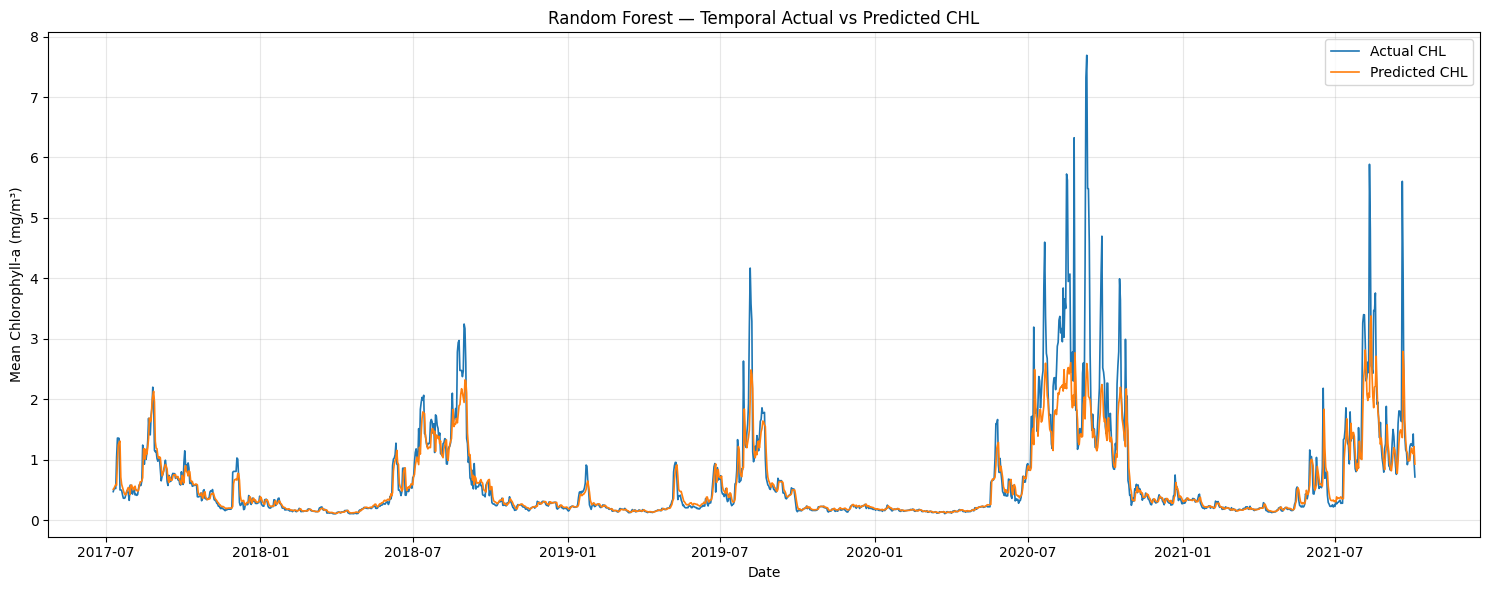

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_temporal_actual_vs_predicted.png

2. MONTHLY ERROR ANALYSIS


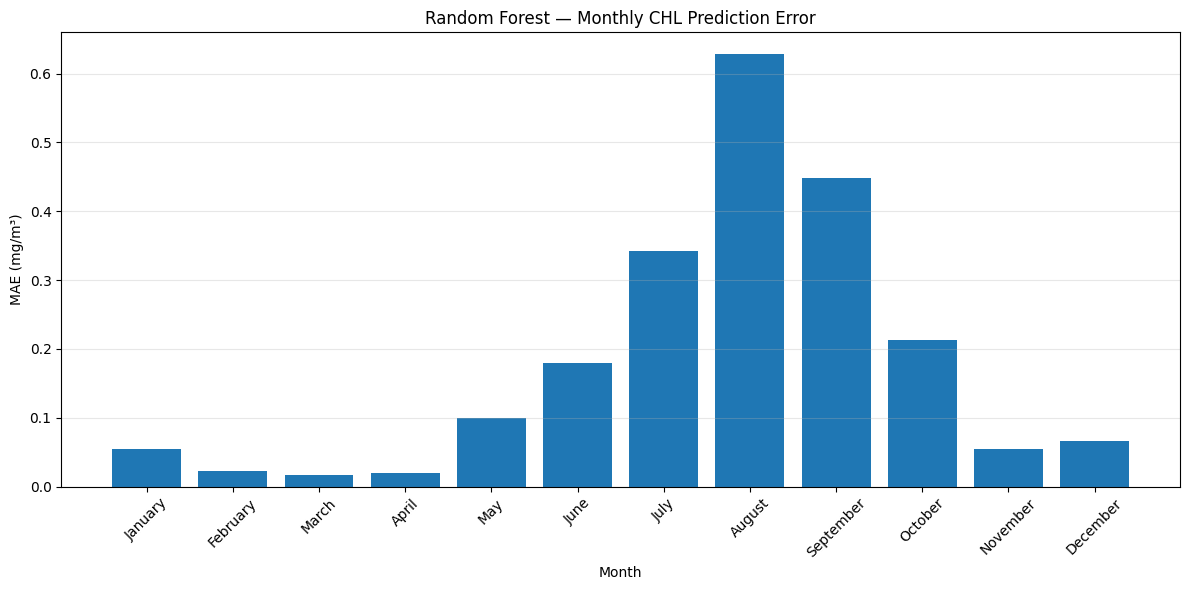

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_monthly_mae.png


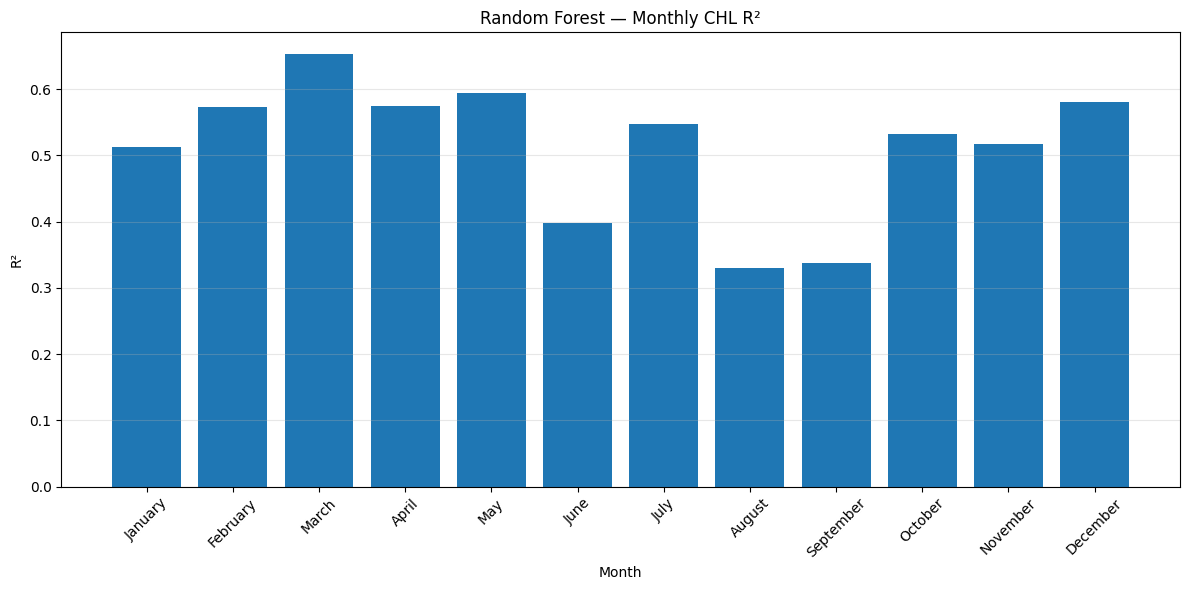

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_monthly_r2.png

4. YEARLY PERFORMANCE VISUALIZATION


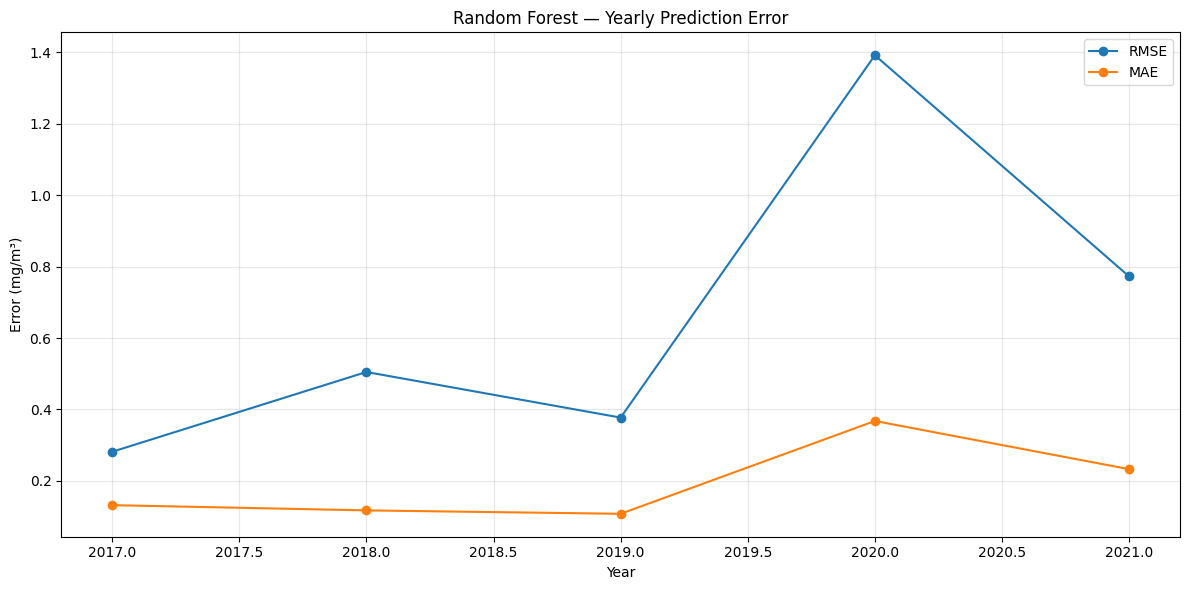

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_yearly_error.png

5. HIGH-CHL EVENT PERFORMANCE


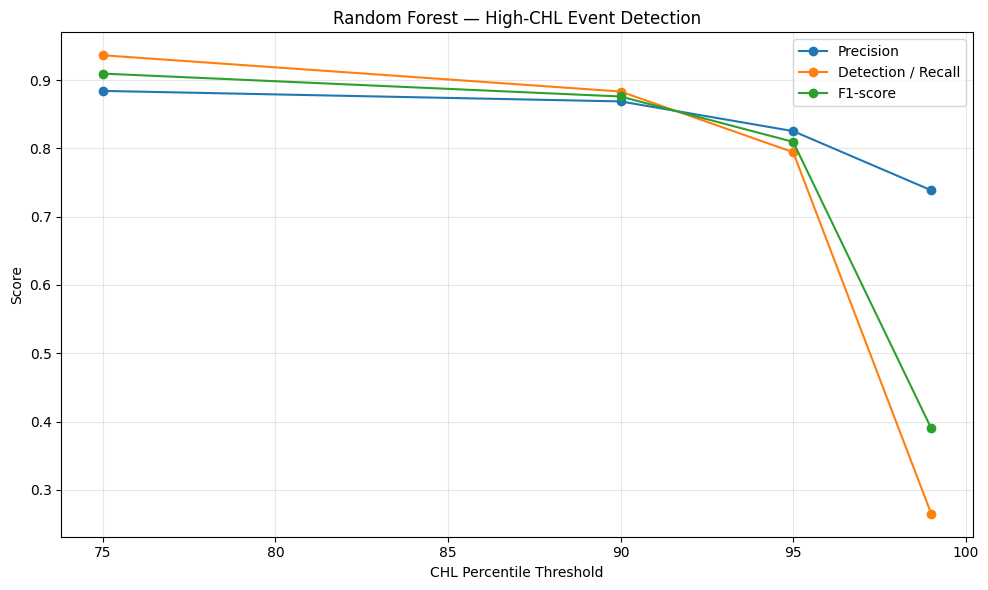

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_high_chl_event_performance.png


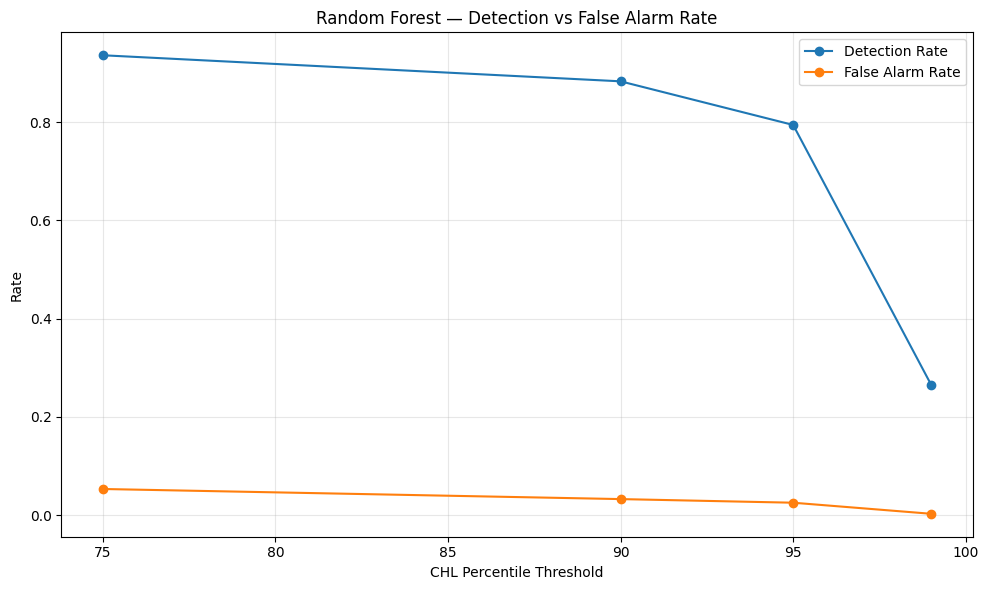

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_high_chl_detection_vs_false_alarm.png

7. SPATIAL PERFORMANCE


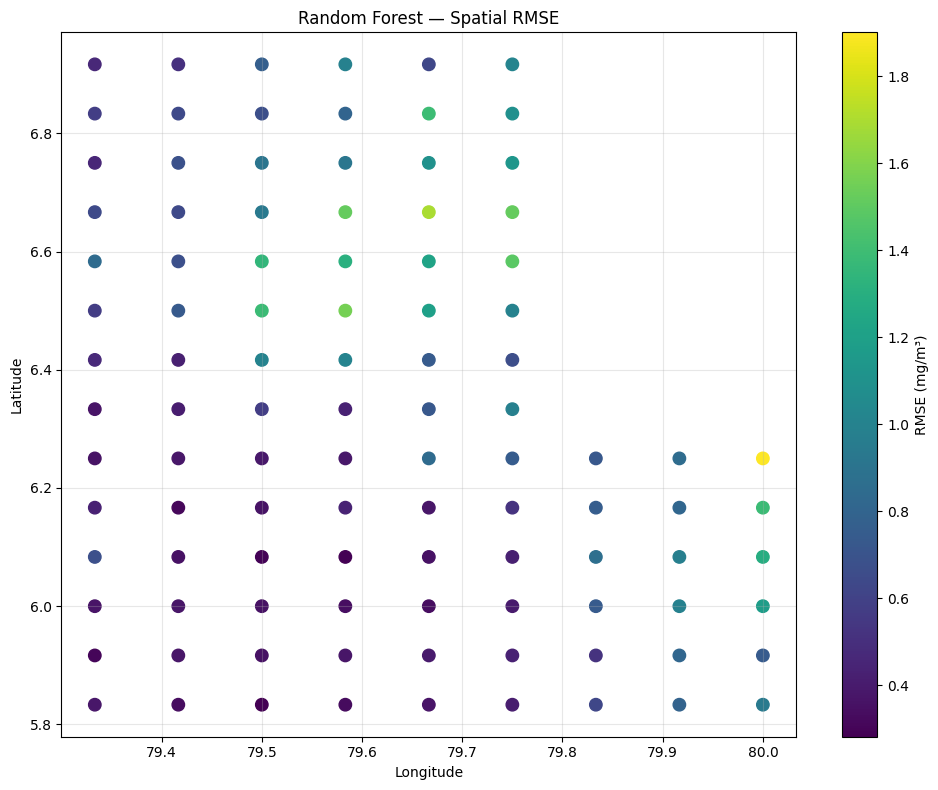

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_spatial_rmse_map.png


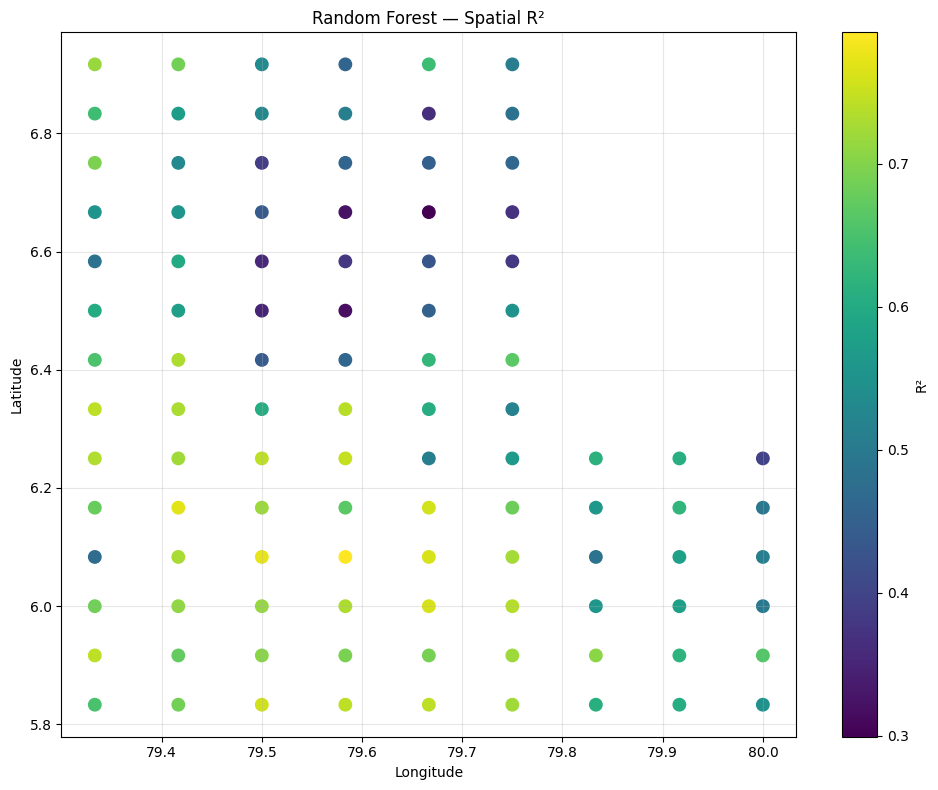

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_spatial_r2_map.png


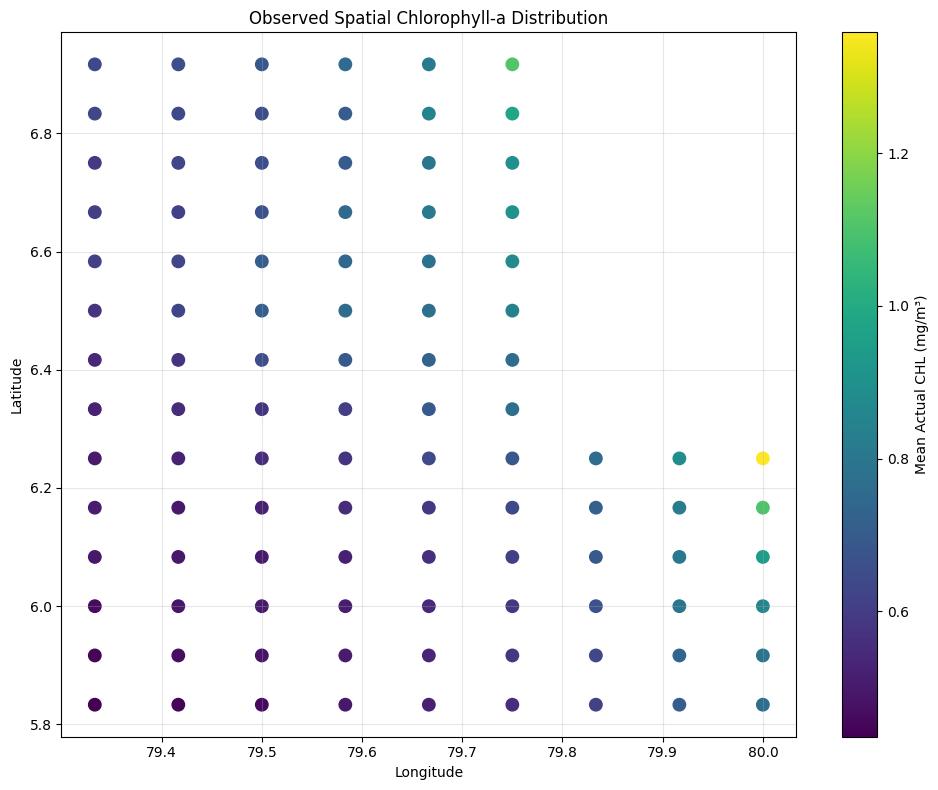

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_spatial_actual_mean_chl.png


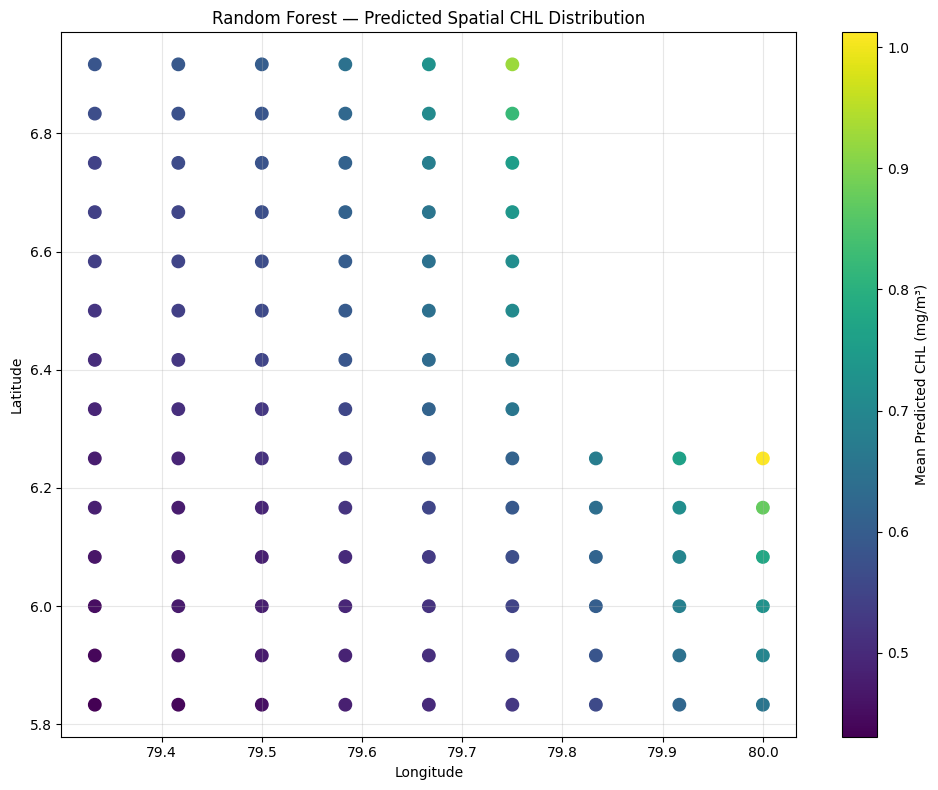

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_spatial_predicted_mean_chl.png


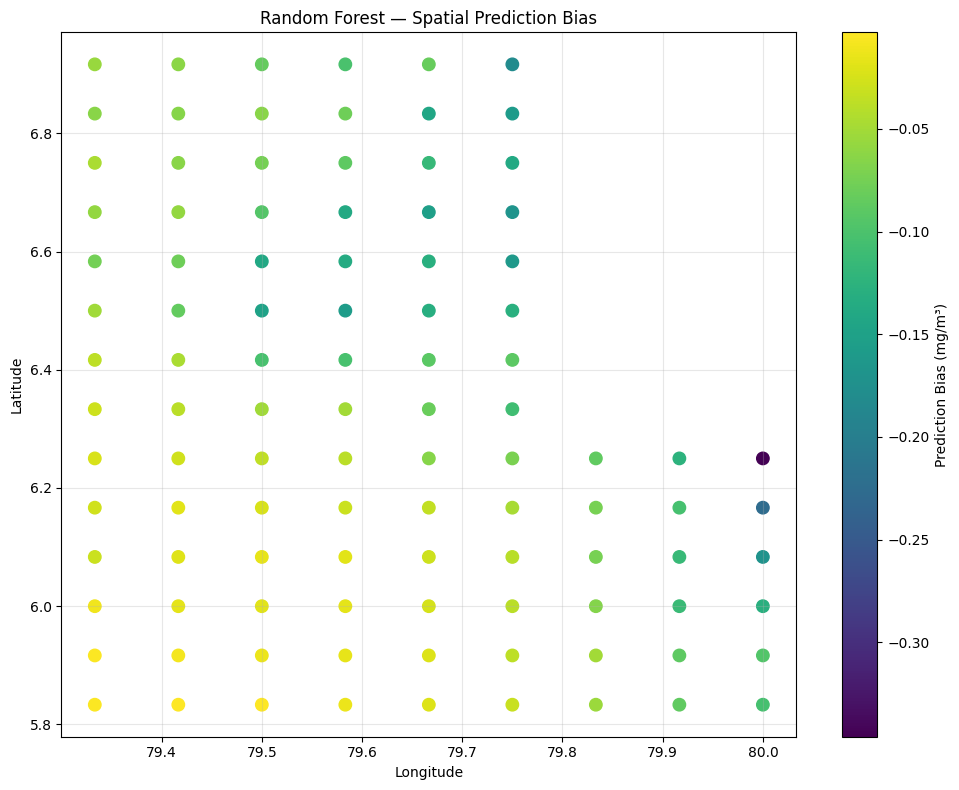

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_spatial_bias_map.png

12. FEATURE IMPORTANCE VISUALIZATION


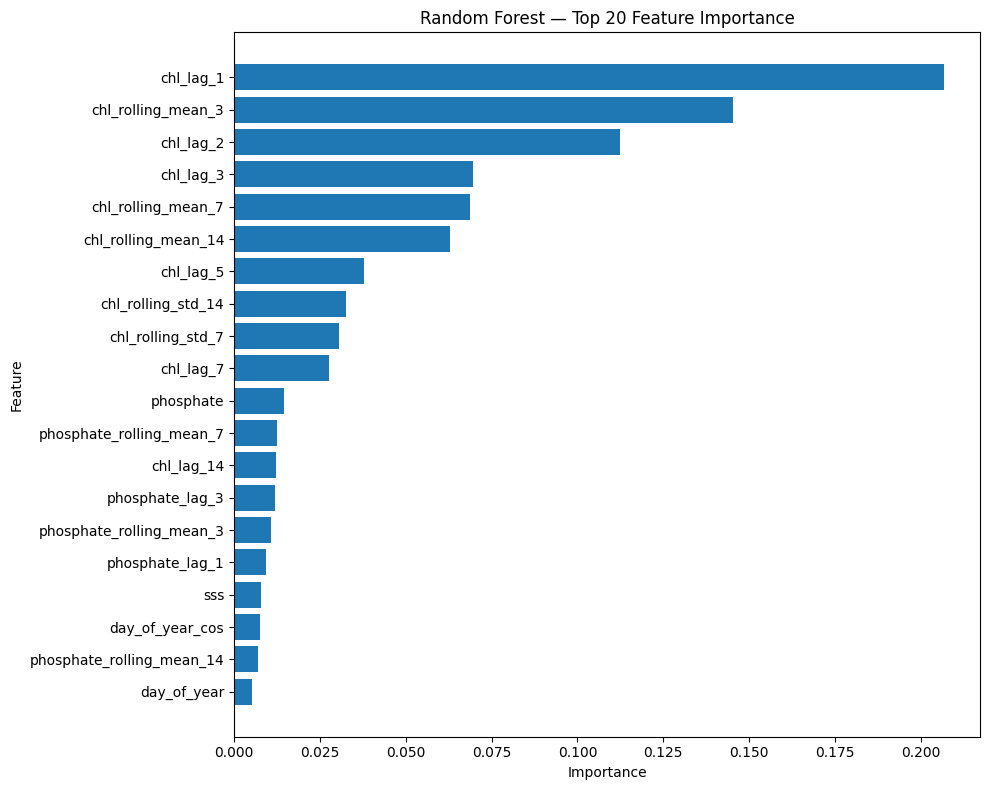

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_top20_feature_importance_final.png

13. SCIENTIFIC FEATURE GROUP CONTRIBUTION
      feature_group  importance
     Historical CHL    0.808801
          Phosphate    0.072304
Temporal / Seasonal    0.039133
                SSS    0.031083
                SST    0.018190
            Nitrate    0.013973
           Silicate    0.013207
            Spatial    0.003310


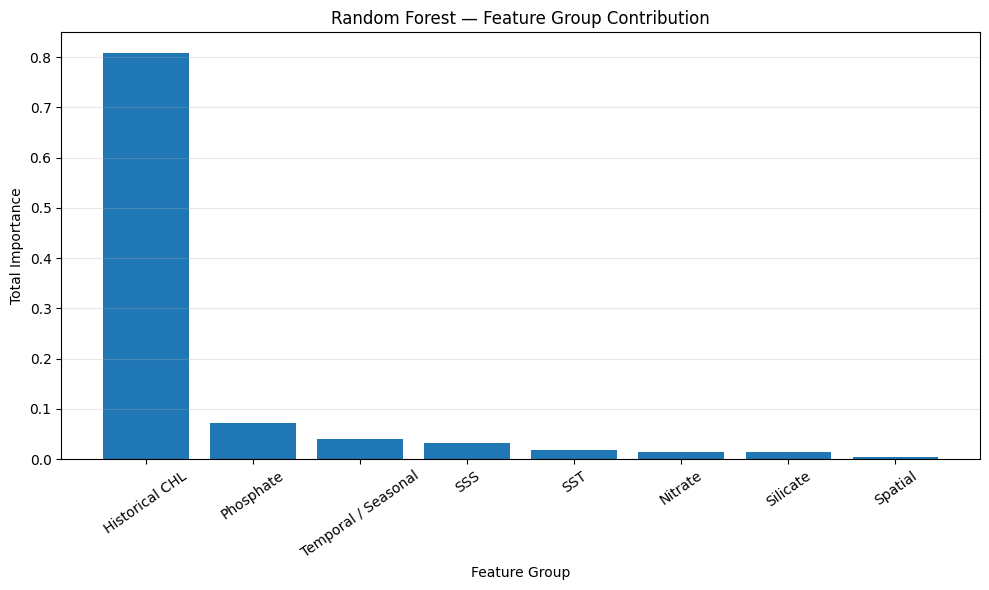

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_feature_group_importance.csv
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_feature_group_importance.png

STEP 31.9P-12C COMPLETE

Generated:
✓ Temporal actual vs predicted analysis
✓ Monthly MAE analysis
✓ Monthly R² analysis
✓ Yearly error analysis
✓ High-CHL event performance
✓ Detection vs false-alarm analysis
✓ Spatial RMSE map
✓ Spatial R² map
✓ Spatial actual CHL map
✓ Spatial predicted CHL map
✓ Spatial bias map
✓ Feature importance analysis
✓ Scientific feature-group contribution

All outputs saved to:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation

Test data:
NOT USED

Next:
STEP 31.9P-12D — RANDOM FOREST ERROR / EXTREME EVENT ANALYSIS


In [2]:
# ======================================================================
# STEP 31.9P-12C — RANDOM FOREST TEMPORAL / EXTREME / SPATIAL ANALYSIS
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("=" * 70)
print("STEP 31.9P-12C — RANDOM FOREST VISUAL ANALYSIS")
print("=" * 70)

# ======================================================================
# PATHS
# ======================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Indhi_Marine_Research_Data"
)

MODEL_DIR = (
    BASE_DIR /
    "06_models" /
    "01_Random_Forest"
)

EVAL_DIR = MODEL_DIR / "evaluation"

# ======================================================================
# LOAD RESULTS
# ======================================================================

diagnostic_file = (
    EVAL_DIR /
    "random_forest_validation_predictions_with_diagnostics.csv"
)

monthly_file = (
    EVAL_DIR /
    "random_forest_monthly_performance.csv"
)

yearly_file = (
    EVAL_DIR /
    "random_forest_yearly_performance.csv"
)

spatial_file = (
    EVAL_DIR /
    "random_forest_spatial_performance.csv"
)

importance_file = (
    EVAL_DIR /
    "random_forest_feature_importance.csv"
)

event_file = (
    EVAL_DIR /
    "random_forest_high_chl_event_metrics.csv"
)

pred_df = pd.read_csv(
    diagnostic_file,
    parse_dates=["date"]
)

monthly_df = pd.read_csv(
    monthly_file
)

yearly_df = pd.read_csv(
    yearly_file
)

spatial_df = pd.read_csv(
    spatial_file
)

importance_df = pd.read_csv(
    importance_file
)

event_df = pd.read_csv(
    event_file
)

print("\n✓ All P-12B evaluation files loaded.")

# ======================================================================
# 1. TEMPORAL ACTUAL VS PREDICTED CHL
# ======================================================================

print("\n" + "=" * 70)
print("1. TEMPORAL CHL COMPARISON")
print("=" * 70)

daily_temporal = (
    pred_df
    .groupby("date")
    .agg(
        actual_CHL=(
            "actual_chlorophyll_a",
            "mean"
        ),
        predicted_CHL=(
            "predicted_chlorophyll_a",
            "mean"
        )
    )
    .reset_index()
)

plt.figure(figsize=(15, 6))

plt.plot(
    daily_temporal["date"],
    daily_temporal["actual_CHL"],
    label="Actual CHL",
    linewidth=1.2
)

plt.plot(
    daily_temporal["date"],
    daily_temporal["predicted_CHL"],
    label="Predicted CHL",
    linewidth=1.2
)

plt.xlabel("Date")
plt.ylabel("Mean Chlorophyll-a (mg/m³)")
plt.title(
    "Random Forest — Temporal Actual vs Predicted CHL"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_temporal_actual_vs_predicted.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 2. MONTHLY MAE
# ======================================================================

print("\n" + "=" * 70)
print("2. MONTHLY ERROR ANALYSIS")
print("=" * 70)

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_df["month_name"],
    monthly_df["MAE"]
)

plt.xlabel("Month")
plt.ylabel("MAE (mg/m³)")
plt.title(
    "Random Forest — Monthly CHL Prediction Error"
)

plt.xticks(rotation=45)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_monthly_mae.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 3. MONTHLY R²
# ======================================================================

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_df["month_name"],
    monthly_df["R2"]
)

plt.xlabel("Month")
plt.ylabel("R²")
plt.title(
    "Random Forest — Monthly CHL R²"
)

plt.xticks(rotation=45)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_monthly_r2.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 4. YEARLY PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("4. YEARLY PERFORMANCE VISUALIZATION")
print("=" * 70)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_df["year"],
    yearly_df["RMSE"],
    marker="o",
    label="RMSE"
)

plt.plot(
    yearly_df["year"],
    yearly_df["MAE"],
    marker="o",
    label="MAE"
)

plt.xlabel("Year")
plt.ylabel("Error (mg/m³)")
plt.title(
    "Random Forest — Yearly Prediction Error"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_yearly_error.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 5. HIGH-CHL EVENT PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("5. HIGH-CHL EVENT PERFORMANCE")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    event_df["percentile"],
    event_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    event_df["percentile"],
    event_df["recall_detection_rate"],
    marker="o",
    label="Detection / Recall"
)

plt.plot(
    event_df["percentile"],
    event_df["f1_score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("CHL Percentile Threshold")
plt.ylabel("Score")
plt.title(
    "Random Forest — High-CHL Event Detection"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_high_chl_event_performance.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 6. HIGH-CHL DETECTION VS FALSE ALARM
# ======================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    event_df["percentile"],
    event_df["recall_detection_rate"],
    marker="o",
    label="Detection Rate"
)

plt.plot(
    event_df["percentile"],
    event_df["false_alarm_rate"],
    marker="o",
    label="False Alarm Rate"
)

plt.xlabel("CHL Percentile Threshold")
plt.ylabel("Rate")
plt.title(
    "Random Forest — Detection vs False Alarm Rate"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_high_chl_detection_vs_false_alarm.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 7. SPATIAL RMSE MAP
# ======================================================================

print("\n" + "=" * 70)
print("7. SPATIAL PERFORMANCE")
print("=" * 70)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    spatial_df["longitude"],
    spatial_df["latitude"],
    c=spatial_df["RMSE"],
    s=80
)

plt.colorbar(
    scatter,
    label="RMSE (mg/m³)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Random Forest — Spatial RMSE"
)

plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_spatial_rmse_map.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 8. SPATIAL R² MAP
# ======================================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    spatial_df["longitude"],
    spatial_df["latitude"],
    c=spatial_df["R2"],
    s=80
)

plt.colorbar(
    scatter,
    label="R²"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Random Forest — Spatial R²"
)

plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_spatial_r2_map.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 9. SPATIAL ACTUAL MEAN CHL
# ======================================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    spatial_df["longitude"],
    spatial_df["latitude"],
    c=spatial_df["actual_mean_CHL"],
    s=80
)

plt.colorbar(
    scatter,
    label="Mean Actual CHL (mg/m³)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Observed Spatial Chlorophyll-a Distribution"
)

plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_spatial_actual_mean_chl.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 10. SPATIAL PREDICTED MEAN CHL
# ======================================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    spatial_df["longitude"],
    spatial_df["latitude"],
    c=spatial_df["predicted_mean_CHL"],
    s=80
)

plt.colorbar(
    scatter,
    label="Mean Predicted CHL (mg/m³)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Random Forest — Predicted Spatial CHL Distribution"
)

plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_spatial_predicted_mean_chl.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 11. SPATIAL BIAS MAP
# ======================================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    spatial_df["longitude"],
    spatial_df["latitude"],
    c=spatial_df["bias"],
    s=80
)

plt.colorbar(
    scatter,
    label="Prediction Bias (mg/m³)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Random Forest — Spatial Prediction Bias"
)

plt.grid(alpha=0.3)
plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_spatial_bias_map.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 12. TOP FEATURE IMPORTANCE
# ======================================================================

print("\n" + "=" * 70)
print("12. FEATURE IMPORTANCE VISUALIZATION")
print("=" * 70)

top_n = 20

top_features = (
    importance_df
    .head(top_n)
    .sort_values(
        "importance"
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest — Top 20 Feature Importance"
)

plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_top20_feature_importance_final.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", file)

# ======================================================================
# 13. FEATURE GROUP IMPORTANCE
# ======================================================================

print("\n" + "=" * 70)
print("13. SCIENTIFIC FEATURE GROUP CONTRIBUTION")
print("=" * 70)

def classify_feature(feature):

    if feature.startswith("chl_"):
        return "Historical CHL"

    if feature.startswith("sst"):
        return "SST"

    if feature.startswith("sss"):
        return "SSS"

    if feature.startswith("nitrate"):
        return "Nitrate"

    if feature.startswith("phosphate"):
        return "Phosphate"

    if feature.startswith("silicate"):
        return "Silicate"

    if (
        feature in [
            "year",
            "month",
            "day",
            "day_of_year",
            "day_of_week",
            "week_of_year"
        ]
        or feature.endswith("_sin")
        or feature.endswith("_cos")
    ):
        return "Temporal / Seasonal"

    if (
        "latitude" in feature
        or "longitude" in feature
        or "spatial" in feature
    ):
        return "Spatial"

    return "Other"


importance_df["feature_group"] = (
    importance_df["feature"]
    .apply(classify_feature)
)

group_importance = (
    importance_df
    .groupby(
        "feature_group"
    )["importance"]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)

print(
    group_importance.to_string(
        index=False
    )
)

GROUP_IMPORTANCE_FILE = (
    EVAL_DIR /
    "rf_feature_group_importance.csv"
)

group_importance.to_csv(
    GROUP_IMPORTANCE_FILE,
    index=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    group_importance["feature_group"],
    group_importance["importance"]
)

plt.xlabel("Feature Group")
plt.ylabel("Total Importance")
plt.title(
    "Random Forest — Feature Group Contribution"
)

plt.xticks(rotation=35)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

file = (
    EVAL_DIR /
    "rf_feature_group_importance.png"
)

plt.savefig(
    file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(GROUP_IMPORTANCE_FILE)
print(file)

# ======================================================================
# 14. FINAL SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("STEP 31.9P-12C COMPLETE")
print("=" * 70)

print("\nGenerated:")
print("✓ Temporal actual vs predicted analysis")
print("✓ Monthly MAE analysis")
print("✓ Monthly R² analysis")
print("✓ Yearly error analysis")
print("✓ High-CHL event performance")
print("✓ Detection vs false-alarm analysis")
print("✓ Spatial RMSE map")
print("✓ Spatial R² map")
print("✓ Spatial actual CHL map")
print("✓ Spatial predicted CHL map")
print("✓ Spatial bias map")
print("✓ Feature importance analysis")
print("✓ Scientific feature-group contribution")

print("\nAll outputs saved to:")
print(EVAL_DIR)

print("\nTest data:")
print("NOT USED")

print("\nNext:")
print("STEP 31.9P-12D — RANDOM FOREST ERROR / EXTREME EVENT ANALYSIS")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
STEP 31.9P-12D — RANDOM FOREST ERROR / EXTREME EVENT ANALYSIS

Prediction file:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/random_forest_validation_predictions.csv

VALIDATION PREDICTIONS LOADED
Shape: (157896, 7)

Columns:
✓ date
✓ latitude
✓ longitude
✓ actual_chlorophyll_a
✓ actual_chlorophyll_a_log1p
✓ predicted_chlorophyll_a_log1p
✓ predicted_chlorophyll_a

✓ Error variables created.

1. OVERALL ERROR SUMMARY
MAE       : 0.196703 mg/m³
RMSE      : 0.817120 mg/m³
R²        : 0.524387
Mean Bias  : 0.074536 mg/m³
Median AE  : 0.039131 mg/m³

2. OVERPREDICTION / UNDERPREDICTION ANALYSIS
Overpredictions : 96,863 (61.35%)
Underpredictions: 61,033 (38.65%)
Exact predictions: 0 (0.00%)

3. ERROR BY CHL RANGE
chl_range  observations  actual_mean  predicted_mean       MAE      RMSE      bias
    0–0.2         53489     0.155520   

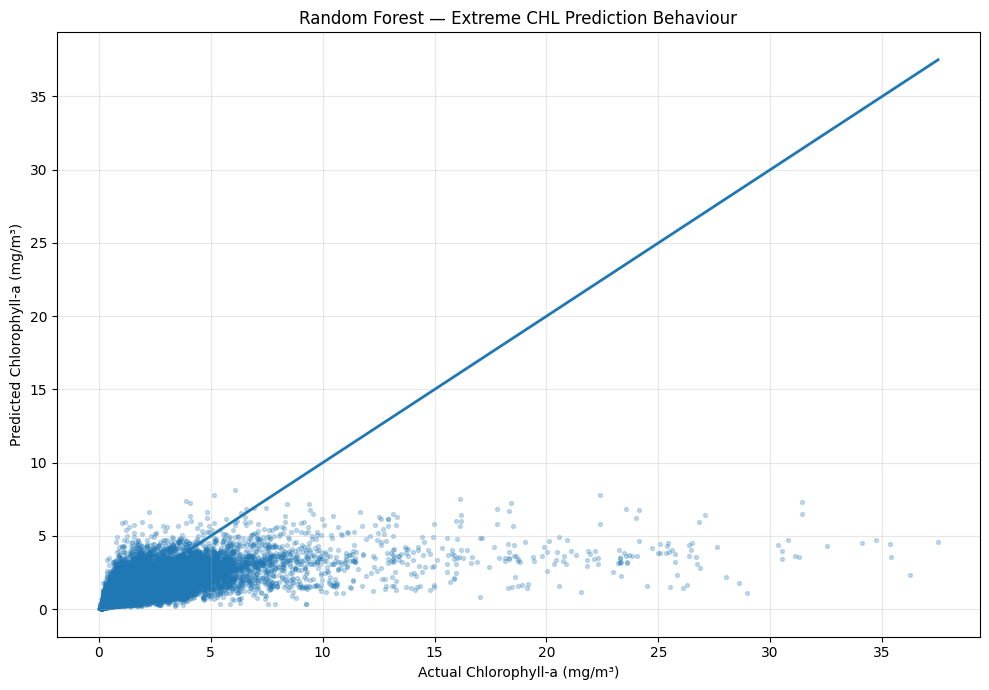

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_extreme_actual_vs_predicted.png

8. ERROR DISTRIBUTION


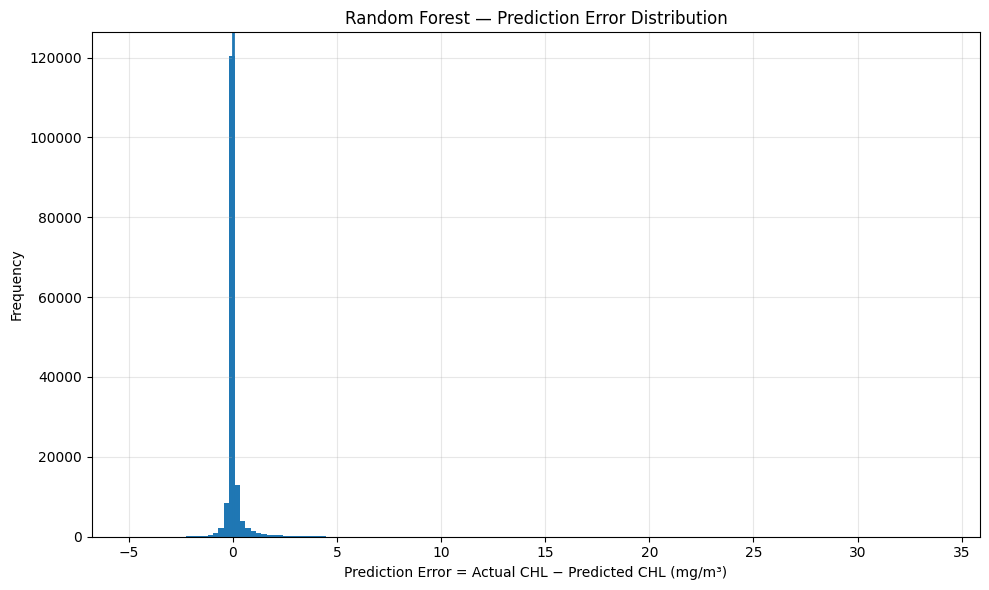

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_error_distribution_detailed.png

9. ERROR VS ACTUAL CHL


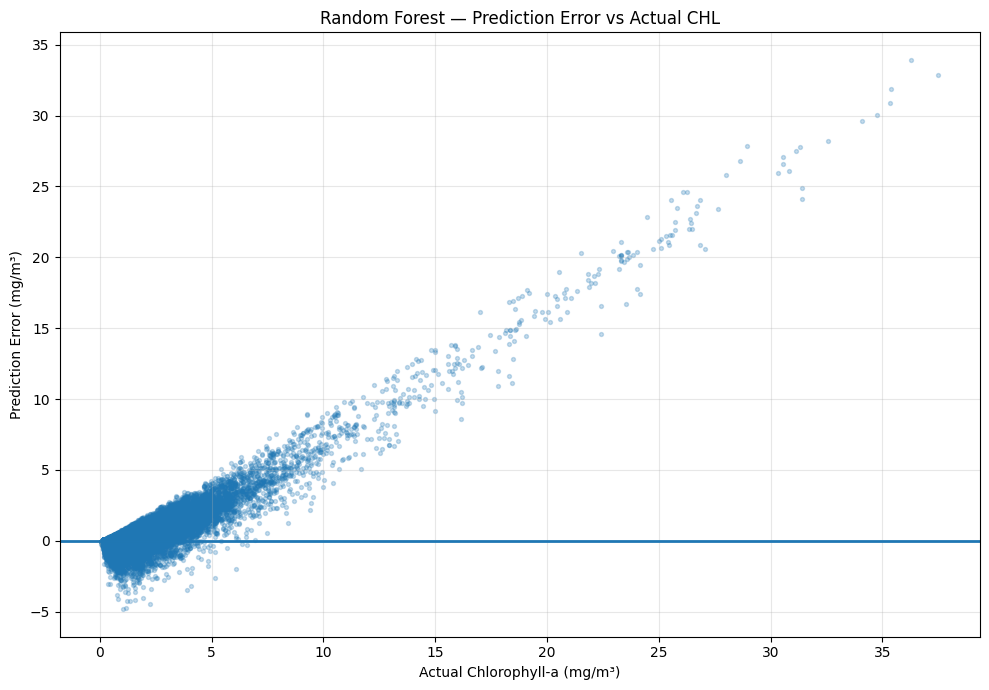

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_error_vs_actual_chl.png

10. YEARLY ERROR SUMMARY
 year  observations      MAE     RMSE      bias  actual_mean  predicted_mean
 2017         17850 0.132112 0.281584 -0.015260     0.609441        0.624701
 2018         37230 0.117419 0.505037  0.020473     0.528928        0.508455
 2019         37230 0.107897 0.377357  0.008675     0.408964        0.400289
 2020         37332 0.367816 1.392120  0.233870     1.011277        0.777408
 2021         28254 0.232908 0.772542  0.078763     0.745965        0.667202

Saved: /content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/rf_yearly_error_detailed.csv

11. FINAL ERROR DIAGNOSTIC SUMMARY
                    metric     value
               Overall MAE  0.196703
              Overall RMSE  0.817120
                Overall R2  0.524387
                 Mean Bias  0.074536
     Median Absolute Error  0.039131
       

In [3]:
# ======================================================================
# STEP 31.9P-12D — RANDOM FOREST ERROR / EXTREME EVENT ANALYSIS
# ======================================================================

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("STEP 31.9P-12D — RANDOM FOREST ERROR / EXTREME EVENT ANALYSIS")
print("=" * 70)


# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = Path(
    "/content/drive/MyDrive/Indhi_Marine_Research_Data"
)

MODEL_DIR = (
    BASE_DIR /
    "06_models" /
    "01_Random_Forest"
)

EVAL_DIR = MODEL_DIR / "evaluation"

EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREDICTION_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

print("\nPrediction file:")
print(PREDICTION_FILE)


# ----------------------------------------------------------------------
# LOAD VALIDATION PREDICTIONS
# ----------------------------------------------------------------------

df = pd.read_csv(PREDICTION_FILE)

df["date"] = pd.to_datetime(df["date"])

print("\n" + "=" * 70)
print("VALIDATION PREDICTIONS LOADED")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
for column in df.columns:
    print("✓", column)


# ----------------------------------------------------------------------
# CREATE ERROR VARIABLES
# ----------------------------------------------------------------------

df["error"] = (
    df["actual_chlorophyll_a"]
    - df["predicted_chlorophyll_a"]
)

df["absolute_error"] = (
    df["error"].abs()
)

df["squared_error"] = (
    df["error"] ** 2
)

df["percentage_error"] = np.where(
    df["actual_chlorophyll_a"] != 0,
    (
        df["absolute_error"]
        / df["actual_chlorophyll_a"]
    ) * 100,
    np.nan
)

print("\n✓ Error variables created.")


# ======================================================================
# 1. OVERALL ERROR SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("1. OVERALL ERROR SUMMARY")
print("=" * 70)

overall_mae = mean_absolute_error(
    df["actual_chlorophyll_a"],
    df["predicted_chlorophyll_a"]
)

overall_rmse = np.sqrt(
    mean_squared_error(
        df["actual_chlorophyll_a"],
        df["predicted_chlorophyll_a"]
    )
)

overall_r2 = r2_score(
    df["actual_chlorophyll_a"],
    df["predicted_chlorophyll_a"]
)

mean_bias = df["error"].mean()

median_abs_error = (
    df["absolute_error"].median()
)

print(f"MAE       : {overall_mae:.6f} mg/m³")
print(f"RMSE      : {overall_rmse:.6f} mg/m³")
print(f"R²        : {overall_r2:.6f}")
print(f"Mean Bias  : {mean_bias:.6f} mg/m³")
print(f"Median AE  : {median_abs_error:.6f} mg/m³")


# ======================================================================
# 2. OVERPREDICTION / UNDERPREDICTION
# ======================================================================

print("\n" + "=" * 70)
print("2. OVERPREDICTION / UNDERPREDICTION ANALYSIS")
print("=" * 70)

overprediction_count = (
    df["error"] < 0
).sum()

underprediction_count = (
    df["error"] > 0
).sum()

exact_count = (
    df["error"] == 0
).sum()

total = len(df)

overprediction_pct = (
    overprediction_count / total * 100
)

underprediction_pct = (
    underprediction_count / total * 100
)

exact_pct = (
    exact_count / total * 100
)

print(
    f"Overpredictions : {overprediction_count:,} "
    f"({overprediction_pct:.2f}%)"
)

print(
    f"Underpredictions: {underprediction_count:,} "
    f"({underprediction_pct:.2f}%)"
)

print(
    f"Exact predictions: {exact_count:,} "
    f"({exact_pct:.2f}%)"
)


# ======================================================================
# 3. ERROR BY CHL RANGE
# ======================================================================

print("\n" + "=" * 70)
print("3. ERROR BY CHL RANGE")
print("=" * 70)

# Scientifically useful CHL ranges for diagnostic analysis.
# These are NOT used to train the model.

bins = [
    0,
    0.2,
    0.5,
    1,
    2,
    5,
    10,
    np.inf
]

labels = [
    "0–0.2",
    "0.2–0.5",
    "0.5–1",
    "1–2",
    "2–5",
    "5–10",
    ">10"
]

df["chl_range"] = pd.cut(
    df["actual_chlorophyll_a"],
    bins=bins,
    labels=labels,
    right=False
)

range_results = (
    df.groupby(
        "chl_range",
        observed=False
    )
    .agg(
        observations=("actual_chlorophyll_a", "size"),
        actual_mean=("actual_chlorophyll_a", "mean"),
        predicted_mean=("predicted_chlorophyll_a", "mean"),
        MAE=("absolute_error", "mean"),
        RMSE=(
            "squared_error",
            lambda x: np.sqrt(x.mean())
        ),
        bias=("error", "mean")
    )
    .reset_index()
)

print(range_results.to_string(index=False))

range_results.to_csv(
    EVAL_DIR /
    "rf_error_by_chl_range.csv",
    index=False
)

print(
    "\nSaved:",
    EVAL_DIR /
    "rf_error_by_chl_range.csv"
)


# ======================================================================
# 4. TRAINING-DERIVED EXTREME CHL THRESHOLDS
# ======================================================================

print("\n" + "=" * 70)
print("4. TRAINING-DERIVED EXTREME CHL THRESHOLDS")
print("=" * 70)

# Load the original training data ONLY to derive thresholds.
# Validation predictions remain completely untouched.

TRAIN_FILE = (
    BASE_DIR /
    "05_model_preprocessing" /
    "final_model_ready_train.csv"
)

train_df = pd.read_csv(
    TRAIN_FILE,
    usecols=["chlorophyll_a"]
)

training_chl = (
    train_df["chlorophyll_a"]
    .dropna()
)

percentiles = [75, 90, 95, 99]

thresholds = {
    p: np.percentile(
        training_chl,
        p
    )
    for p in percentiles
}

for p, threshold in thresholds.items():
    print(
        f"{p}th percentile threshold: "
        f"{threshold:.6f} mg/m³"
    )


# ======================================================================
# 5. EXTREME EVENT ERROR ANALYSIS
# ======================================================================

print("\n" + "=" * 70)
print("5. EXTREME CHL EVENT ERROR ANALYSIS")
print("=" * 70)

event_results = []

for percentile, threshold in thresholds.items():

    event_mask = (
        df["actual_chlorophyll_a"]
        >= threshold
    )

    event_df = df.loc[event_mask]

    if len(event_df) == 0:
        continue

    event_mae = mean_absolute_error(
        event_df["actual_chlorophyll_a"],
        event_df["predicted_chlorophyll_a"]
    )

    event_rmse = np.sqrt(
        mean_squared_error(
            event_df["actual_chlorophyll_a"],
            event_df["predicted_chlorophyll_a"]
        )
    )

    event_bias = (
        event_df["error"].mean()
    )

    event_results.append({
        "percentile": percentile,
        "threshold_mg_m3": threshold,
        "event_observations": len(event_df),
        "event_MAE": event_mae,
        "event_RMSE": event_rmse,
        "event_bias": event_bias,
        "actual_mean": event_df[
            "actual_chlorophyll_a"
        ].mean(),
        "predicted_mean": event_df[
            "predicted_chlorophyll_a"
        ].mean(),
        "actual_max": event_df[
            "actual_chlorophyll_a"
        ].max(),
        "predicted_max": event_df[
            "predicted_chlorophyll_a"
        ].max()
    })

event_results_df = pd.DataFrame(
    event_results
)

print(
    event_results_df.to_string(index=False)
)

event_results_df.to_csv(
    EVAL_DIR /
    "rf_extreme_chl_error_analysis.csv",
    index=False
)

print(
    "\nSaved:",
    EVAL_DIR /
    "rf_extreme_chl_error_analysis.csv"
)


# ======================================================================
# 6. LARGEST PREDICTION ERRORS
# ======================================================================

print("\n" + "=" * 70)
print("6. LARGEST PREDICTION ERRORS")
print("=" * 70)

largest_errors = (
    df.sort_values(
        "absolute_error",
        ascending=False
    )
    [
        [
            "date",
            "latitude",
            "longitude",
            "actual_chlorophyll_a",
            "predicted_chlorophyll_a",
            "error",
            "absolute_error"
        ]
    ]
    .head(100)
)

print(
    largest_errors.head(20).to_string(
        index=False
    )
)

largest_errors.to_csv(
    EVAL_DIR /
    "rf_largest_prediction_errors_top100.csv",
    index=False
)

print(
    "\nSaved:",
    EVAL_DIR /
    "rf_largest_prediction_errors_top100.csv"
)


# ======================================================================
# 7. EXTREME ACTUAL CHL VS PREDICTED CHL
# ======================================================================

print("\n" + "=" * 70)
print("7. EXTREME ACTUAL VS PREDICTED CHL")
print("=" * 70)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    df["actual_chlorophyll_a"],
    df["predicted_chlorophyll_a"],
    s=8,
    alpha=0.25
)

max_value = max(
    df["actual_chlorophyll_a"].max(),
    df["predicted_chlorophyll_a"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linewidth=2
)

plt.xlabel(
    "Actual Chlorophyll-a (mg/m³)"
)

plt.ylabel(
    "Predicted Chlorophyll-a (mg/m³)"
)

plt.title(
    "Random Forest — Extreme CHL Prediction Behaviour"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

extreme_scatter_file = (
    EVAL_DIR /
    "rf_extreme_actual_vs_predicted.png"
)

plt.savefig(
    extreme_scatter_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    extreme_scatter_file
)


# ======================================================================
# 8. ERROR DISTRIBUTION
# ======================================================================

print("\n" + "=" * 70)
print("8. ERROR DISTRIBUTION")
print("=" * 70)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df["error"],
    bins=150
)

plt.axvline(
    0,
    linewidth=2
)

plt.xlabel(
    "Prediction Error = Actual CHL − Predicted CHL (mg/m³)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Random Forest — Prediction Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

error_distribution_file = (
    EVAL_DIR /
    "rf_error_distribution_detailed.png"
)

plt.savefig(
    error_distribution_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    error_distribution_file
)


# ======================================================================
# 9. ERROR VS ACTUAL CHL
# ======================================================================

print("\n" + "=" * 70)
print("9. ERROR VS ACTUAL CHL")
print("=" * 70)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    df["actual_chlorophyll_a"],
    df["error"],
    s=8,
    alpha=0.25
)

plt.axhline(
    0,
    linewidth=2
)

plt.xlabel(
    "Actual Chlorophyll-a (mg/m³)"
)

plt.ylabel(
    "Prediction Error (mg/m³)"
)

plt.title(
    "Random Forest — Prediction Error vs Actual CHL"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

error_vs_actual_file = (
    EVAL_DIR /
    "rf_error_vs_actual_chl.png"
)

plt.savefig(
    error_vs_actual_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    error_vs_actual_file
)


# ======================================================================
# 10. ERROR SUMMARY BY YEAR
# ======================================================================

print("\n" + "=" * 70)
print("10. YEARLY ERROR SUMMARY")
print("=" * 70)

df["year"] = df["date"].dt.year

year_results = (
    df.groupby("year")
    .agg(
        observations=("actual_chlorophyll_a", "size"),
        MAE=("absolute_error", "mean"),
        RMSE=(
            "squared_error",
            lambda x: np.sqrt(x.mean())
        ),
        bias=("error", "mean"),
        actual_mean=("actual_chlorophyll_a", "mean"),
        predicted_mean=("predicted_chlorophyll_a", "mean")
    )
    .reset_index()
)

print(
    year_results.to_string(index=False)
)

year_results.to_csv(
    EVAL_DIR /
    "rf_yearly_error_detailed.csv",
    index=False
)

print(
    "\nSaved:",
    EVAL_DIR /
    "rf_yearly_error_detailed.csv"
)


# ======================================================================
# 11. FINAL ERROR DIAGNOSTIC SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("11. FINAL ERROR DIAGNOSTIC SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    "metric": [
        "Overall MAE",
        "Overall RMSE",
        "Overall R2",
        "Mean Bias",
        "Median Absolute Error",
        "Maximum Actual CHL",
        "Maximum Predicted CHL",
        "Maximum Absolute Error",
        "Underprediction percentage",
        "Overprediction percentage"
    ],
    "value": [
        overall_mae,
        overall_rmse,
        overall_r2,
        mean_bias,
        median_abs_error,
        df["actual_chlorophyll_a"].max(),
        df["predicted_chlorophyll_a"].max(),
        df["absolute_error"].max(),
        underprediction_pct,
        overprediction_pct
    ]
})

print(
    summary.to_string(index=False)
)

summary.to_csv(
    EVAL_DIR /
    "rf_error_diagnostic_summary.csv",
    index=False
)


# ======================================================================
# COMPLETE
# ======================================================================

print("\n" + "=" * 70)
print("STEP 31.9P-12D COMPLETE")
print("=" * 70)

print("""
✓ Overall error analysed
✓ Overprediction / underprediction analysed
✓ Error analysed by CHL range
✓ Training-derived percentile thresholds calculated
✓ Extreme CHL event errors analysed
✓ Largest prediction errors identified
✓ Extreme actual-vs-predicted behaviour visualised
✓ Detailed residual distribution generated
✓ Error vs actual CHL analysed
✓ Yearly error statistics generated

✓ Test data was NOT used for evaluation.
✓ Extreme thresholds were derived from TRAINING data only.

All outputs saved to:
""")

print(EVAL_DIR)

print("\nNext:")
print("STEP 31.9P-12E — RANDOM FOREST FINAL VALIDATION SUMMARY")